# 🦟 Malaria Outbreak Prediction Using Climate and Health Data

---

## 📘 Overview

This notebook presents a **comprehensive machine learning pipeline** developed to predict **malaria outbreaks** using a rich collection of both **climatic** and **health-related features**. The main goal is to proactively forecast malaria incidence, enabling timely intervention and optimized resource allocation, particularly in regions prone to outbreaks.

---

## 🎯 Objective

The key objective of this study is:

> **To train a predictive model capable of accurately estimating malaria outbreaks using historical environmental and medical data.**

---

## 🧠 What You'll Find in This Notebook

This notebook is structured step-by-step, with detailed explanations before each code cell. You can follow the entire process without reading any code — just read the markdowns for a full understanding. The process includes:

1. **🔍 Data Exploration**  
   - Understanding the dataset: sources, structure, and features  
   - Visualizing distributions and trends of key variables

2. **🧼 Data Preprocessing**  
   - Handling missing values, outliers, and anomalies  
   - Feature engineering and selection

3. **📊 Feature Insights**  
   - Analyzing the impact of variables such as:
     - 🌧️ Rainfall
     - 🌡️ Max & Min Temperature
     - 🛏️ Mosquito Net Distribution
     - 🏥 Hospital Patient Records
     - 📈 Historical Malaria Cases

4. **🤖 Model Training**  
   - Splitting the dataset into training and testing sets  
   - Trying out different machine learning algorithms  
   - Evaluating performance using accuracy, recall, precision, F1 score, and ROC-AUC

5. **🧪 Model Evaluation & Interpretation**  
   - Visualizing performance metrics  
   - Understanding feature importances  
   - Calibrating and improving the model

6. **🚀 Final Deployment Ready Model**  
   - The best model will be saved and prepared for future deployment in malaria surveillance systems

---

## 📦 Tools & Libraries Used

- **Python** 🐍
- **Pandas** & **NumPy** for data manipulation  
- **Matplotlib** & **Seaborn** for data visualization  
- **Scikit-learn**, **XGBoost**, or similar for modeling  
- **Joblib/Pickle** for saving the final model

---

## 🧭 Real-World Impact

> This project simulates a real-world solution to support **public health officials**, **NGOs**, and **government agencies** by forecasting malaria outbreaks based on quantifiable indicators. By bridging data science and public health, this model serves as a proactive step toward **disease prevention and control**.

---

🔗 Let’s begin our journey of **data-driven malaria prediction**. Scroll through and explore each step with rich visualizations and intuitive commentary—**no code-reading required**! ✅


## 🛠️ Library Imports & Initial Setup

---

### 📦 In this cell, we perform all the essential library imports and setup tasks required for the entire notebook. This foundational step ensures that we have access to all the tools needed for:

- 📊 **Data manipulation** with `pandas`, `numpy`
- 📈 **Visualization** using `matplotlib` and `seaborn`
- 🧠 **Machine learning and modeling** through `scikit-learn`, `xgboost`, and `statsmodels`
- 🔧 **Preprocessing utilities** for scaling, encoding, imputing, and pipeline building
- 📉 **Time-series analysis** using `seasonal_decompose`
- 🧪 **Evaluation metrics** such as accuracy, precision, recall, F1 score, ROC-AUC

---

### 🔒 Additional Setup

- Warnings are suppressed using `warnings.filterwarnings('ignore')` to ensure a cleaner output during execution.
- Plotting aesthetics are configured using Seaborn’s dark grid theme and a custom color palette (`husl`) to make all visualizations more readable and appealing.

---

> This cell acts as the **toolkit** for the rest of the notebook — ensuring all necessary packages are loaded and properly styled before we dive into data analysis and modeling.


In [149]:

import pandas as pd
import numpy as np
import os
import re
import datetime

# Data manipulation and analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Additional utilities
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.impute import KNNImputer
# Set visualization style
sns.set_style("darkgrid")
sns.set_palette("husl")


## 🌧️ Rainfall Data Cleaning & Consolidation

---

### 🧹 What This Cell Does

This cell performs a **critical data preprocessing step** for our malaria prediction pipeline by:

1. **Defining a custom function** called `clean_climate_data()` that:
   - Reads raw climate Excel files (which may have inconsistent formatting)
   - Extracts and standardizes relevant information such as:
     - 📍 `District`
     - 📍 `Station`
     - 📅 `Year`, `Month`, and `Week`
     - 📏 Climate measurement (e.g., **Rainfall**)
   - Cleans and reshapes the data into a **long-form DataFrame** suitable for analysis

2. **Applying the cleaning function** across all rainfall Excel files stored in the `../RawDataset/rainfall` directory

3. **Combining all processed DataFrames** into a single dataset

4. **Saving the cleaned and structured rainfall data** as a CSV file for future use:
   - ✅ Output path: `../RawDataset/rainfall/combined_rainfall_data.csv`

5. **Displaying a preview** of the cleaned rainfall dataset

---

### 🧠 Why It Matters

> Raw climate data often comes in non-standard Excel formats, making it unsuitable for direct analysis or modeling.  
> This function is designed to **programmatically detect, clean, and extract structured insights** from such raw files, making it a crucial step toward ensuring **data quality and consistency**.

---

### 🔍 Notes on the Extraction Logic

- District and Station names are extracted from the top rows of each Excel file.
- The data is organized in **blocks of 5 rows per year**, with each block containing:
  - 1 header row for months
  - 4 rows of weekly data
- Each data point is labeled with its corresponding year, month, week, and measurement value.

---

📌 At the end of this step, we obtain a **single, clean, and analysis-ready DataFrame** of rainfall values across districts, stations, months, and weeks — ready for merging with other predictors like temperature, net distribution, and hospital cases.



In [150]:

def clean_climate_data(file_path, output_column_name):
    """
    Cleans climate data Excel files and returns a standardized DataFrame.
    
    Parameters:
    - file_path: Path to Excel file
    - output_column_name: Name for the measurement column (e.g., 'Rainfall')
    
    Returns:
    - DataFrame with District, Station, Year, Month, Week, and measurement columns
    """
    # Read Excel file without assuming headers
    raw_df = pd.read_excel(file_path, header=None)
    
    # Initialize district and station variables
    district = station = None
    
    # Search first 5 rows and columns for district/station info
    for i in range(5):
        for j in range(5):
            cell_value = str(raw_df.iloc[i, j])
            if 'District' in cell_value:
                district = cell_value.split(':')[1].strip() if ':' in cell_value else 'Unknown'
            if 'Station' in cell_value:
                station = cell_value.split(':')[-1].strip() if ':' in cell_value else 'Unknown'
    
    print(district)
    # Fallback if district not found
    district = district if district else station
    # Process yearly data blocks
    cleaned_rows = []
    current_row = 0
    
    while current_row < len(raw_df):
        row_data = raw_df.iloc[current_row]
        first_cell = str(row_data.iloc[0]).strip()
        
        # Check if row starts a new year block (4-digit year)
        if re.match(r'^\d{4}$', first_cell):
            year = int(first_cell)
            months = raw_df.iloc[current_row].iloc[1:13].tolist()
            weekly_data = raw_df.iloc[current_row+1:current_row+5].reset_index(drop=True)
            
            # Process each week (4 weeks per month)
            for week_number in range(4):
                week_label = weekly_data.iloc[week_number, 0]
                for month_idx in range(12):
                    month_name = months[month_idx]
                    measurement = weekly_data.iloc[week_number, month_idx + 1]
                    
                    cleaned_rows.append({
                        'District': district,
                        'Station': station,
                        'Year': year,
                        'Month': month_name,
                        'Week': week_label,
                        output_column_name: measurement
                    })
            
            current_row += 5  # Skip to next year block
        else:
            current_row += 1  # Move to next row
    
    return pd.DataFrame(cleaned_rows)


In [151]:

# Configuration
RAINFALL_DIR = '../RawDataset/rainfall'
rainfall_data_frames = []

# Process each rainfall file
print("Processing rainfall data files:")
for filename in os.listdir(RAINFALL_DIR):
    if filename.endswith('.xlsx'):
        file_path = os.path.join(RAINFALL_DIR, filename)
        print(f"- {filename}")
        df = clean_climate_data(file_path, "Rainfall")
        rainfall_data_frames.append(df)

# Combine all rainfall data
combined_rainfall_df = pd.concat(rainfall_data_frames, ignore_index=True)

# Save combined data
rainfall_output_path = '../RawDataset/rainfall/combined_rainfall_data.csv'
combined_rainfall_df.to_csv(rainfall_output_path, index=False)
print(f"\nSaved combined rainfall data to {rainfall_output_path}")

# Show sample data
print("\nSample rainfall data:")
combined_rainfall_df.head()

Processing rainfall data files:
- rain_unguja_magharibi_b.xlsx
MAGHARIBI  B
- WETE.xlsx
WETE
- rain_unguja_kusini.xlsx
KUSINI
- mjini.xlsx
MJINI
- Micheweni.xlsx
MICHEWENI
- rain_unguja_kas_b.xlsx
KASKAZINI B
- rain_unguja_magharibi_a.xlsx
MAGHARIBI  A
- rain_unguja_kas_a.xlsx
KASKAZINI A
- Mkoani.xlsx
MKOANI
- Chake-Chake.xlsx
CHAKE-CHAKE

Saved combined rainfall data to ../RawDataset/rainfall/combined_rainfall_data.csv

Sample rainfall data:


,District,Station,Year,Month,Week,Rainfall
0,MAGHARIBI B,Zanzibar Airport,2023,Jan,1st week,3.8
1,MAGHARIBI B,Zanzibar Airport,2023,Feb,1st week,0.0
2,MAGHARIBI B,Zanzibar Airport,2023,Mar,1st week,0.0
3,MAGHARIBI B,Zanzibar Airport,2023,Apr,1st week,51.6
4,MAGHARIBI B,Zanzibar Airport,2023,May,1st week,69.6



# Rainfall Data Visualization
Let's visualize the distribution of rainfall measurements across different regions and years.


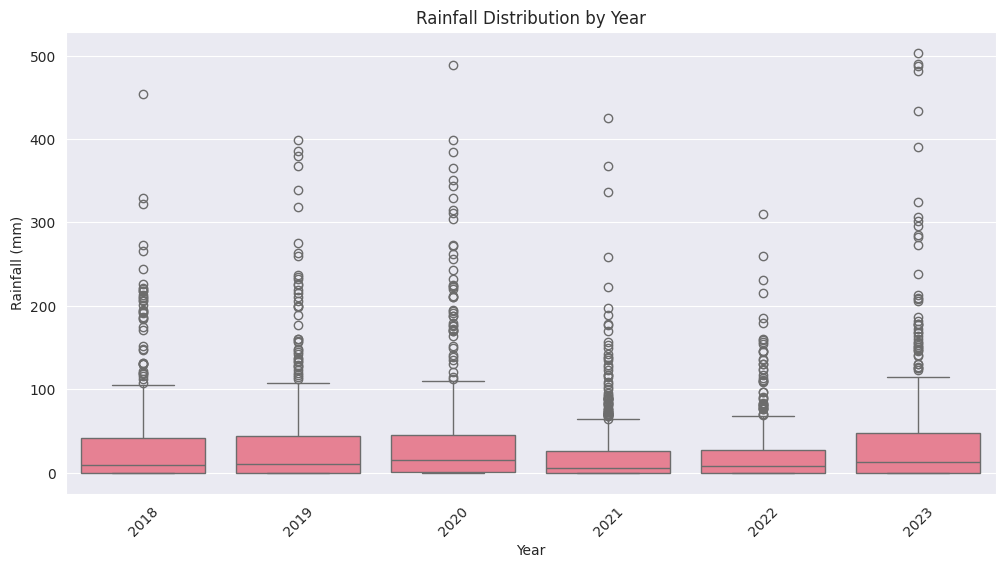

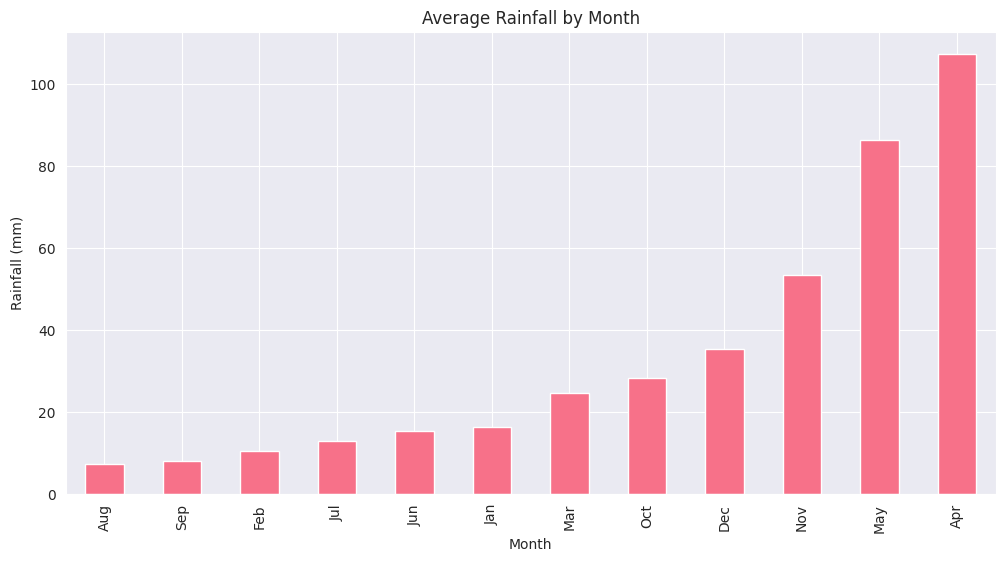

In [152]:

# Plot rainfall distribution by year
plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='Rainfall', data=combined_rainfall_df)
plt.title('Rainfall Distribution by Year')
plt.xticks(rotation=45)
plt.ylabel('Rainfall (mm)')
plt.show()

# Plot average rainfall by month
plt.figure(figsize=(12, 6))
combined_rainfall_df.groupby('Month')['Rainfall'].mean().sort_values().plot(kind='bar')
plt.title('Average Rainfall by Month')
plt.ylabel('Rainfall (mm)')
plt.show()


## 🌡️ Temperature Data Cleaning & Integration

---

### 🔥 Processing Maximum and Minimum Temperature Files

This cell continues our climate data preprocessing by cleaning and merging **maximum** and **minimum temperature** datasets, following the same robust logic used for rainfall data.

---

### 📋 Step-by-Step Breakdown

#### 🟥 1. Maximum Temperature
- 📂 Target Directory: `../RawDataset/temperatures/max_temp`
- 🧼 For each `.xlsx` file:
  - Cleaned using the `clean_climate_data()` function with `"Max Temperature"` as the measurement label.
  - Stored in a list of individual DataFrames.
- 🧩 All cleaned DataFrames are **merged into one** using `pd.concat()`.
- 💾 The combined dataset is **exported to CSV**:
  - `../RawDataset/temperatures/max_temp/combined_max_temperature_data.csv`

#### 🟦 2. Minimum Temperature
- 📂 Target Directory: `../RawDataset/temperatures/min_temp`
- 🧼 Similar cleaning process with `"Min Temperature"` as the output column name.
- 🧩 Cleaned and merged into one consolidated DataFrame.
- 💾 Saved as:
  - `../RawDataset/temperatures/min_temp/combined_min_temperature_data.csv`

---

### 📈 Why This Step Is Important

> Accurate temperature data is **highly correlated with mosquito breeding patterns** and malaria transmission rates.

- **High temperatures** can accelerate mosquito development and increase biting rates.
- **Low temperatures**, especially in cooler months, may suppress mosquito activity.
- By breaking temperatures down by **district, station, year, month, and week**, we gain fine-grained control for analysis and modeling.

---

### 👁️ Output Preview
- A sample preview of the **maximum temperature data** is printed to verify structure and content before further integration.

---

🧠 These cleaned datasets will later be **merged with other features** like rainfall, net distribution, and patient data to build a powerful predictive model for malaria outbreaks.


In [153]:

# Process maximum temperature data
MAX_TEMP_DIR = '../RawDataset/temperatures/max_temp'
max_temp_data_frames = []

print("\nProcessing maximum temperature data files:")
for filename in os.listdir(MAX_TEMP_DIR):
    if filename.endswith('.xlsx'):
        file_path = os.path.join(MAX_TEMP_DIR, filename)
        print(f"- {filename}")
        df = clean_climate_data(file_path, "Max Temperature")
        max_temp_data_frames.append(df)

combined_max_temp_df = pd.concat(max_temp_data_frames, ignore_index=True)
max_temp_output_path = '../RawDataset/temperatures/max_temp/combined_max_temperature_data.csv'
combined_max_temp_df.to_csv(max_temp_output_path, index=False)
print(f"\nSaved combined max temperature data to {max_temp_output_path}")

# Process minimum temperature data
MIN_TEMP_DIR = '../RawDataset/temperatures/min_temp'
min_temp_data_frames = []

print("\nProcessing minimum temperature data files:")
for filename in os.listdir(MIN_TEMP_DIR):
    if filename.endswith('.xlsx'):
        file_path = os.path.join(MIN_TEMP_DIR, filename)
        print(f"- {filename}")
        df = clean_climate_data(file_path, "Min Temperature")
        min_temp_data_frames.append(df)

combined_min_temp_df = pd.concat(min_temp_data_frames, ignore_index=True)
min_temp_output_path = '../RawDataset/temperatures/min_temp/combined_min_temperature_data.csv'
combined_min_temp_df.to_csv(min_temp_output_path, index=False)
print(f"\nSaved combined min temperature data to {min_temp_output_path}")

# Show sample data
print("\nSample temperature data:")
print("Max Temperature:")
combined_max_temp_df.head()



Processing maximum temperature data files:
- unguja_max_temp.xlsx
None
- Maximum. t pemba.xlsx
None

Saved combined max temperature data to ../RawDataset/temperatures/max_temp/combined_max_temperature_data.csv

Processing minimum temperature data files:
- unguja_min_temp.xlsx
None
- MINIMUM pemba.xlsx
None

Saved combined min temperature data to ../RawDataset/temperatures/min_temp/combined_min_temperature_data.csv

Sample temperature data:
Max Temperature:


,District,Station,Year,Month,Week,Max Temperature
0,Zanzibar,Zanzibar,2023,Jan,1st week,32.142857
1,Zanzibar,Zanzibar,2023,Feb,1st week,33.357143
2,Zanzibar,Zanzibar,2023,Mar,1st week,33.914286
3,Zanzibar,Zanzibar,2023,Apr,1st week,31.585714
4,Zanzibar,Zanzibar,2023,May,1st week,30.885714


### Temperature Data Visualization

Visualizing temperature trends helps understand seasonal patterns and anomalies.


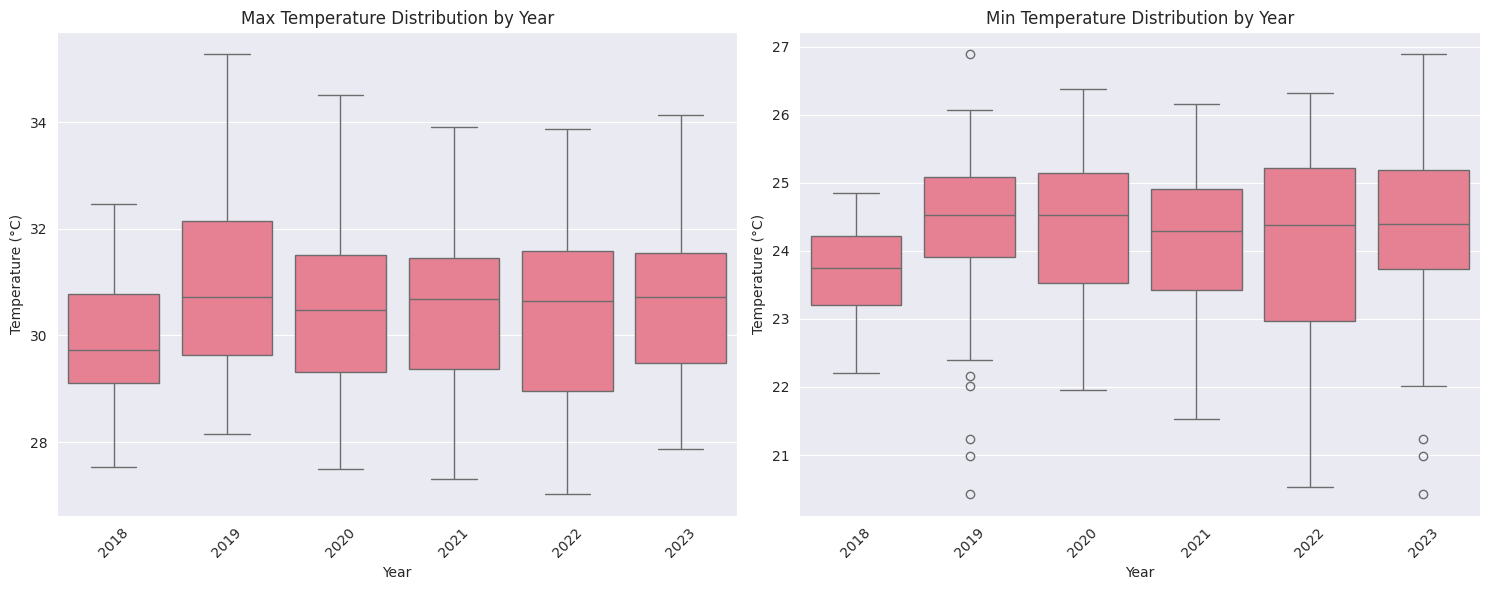

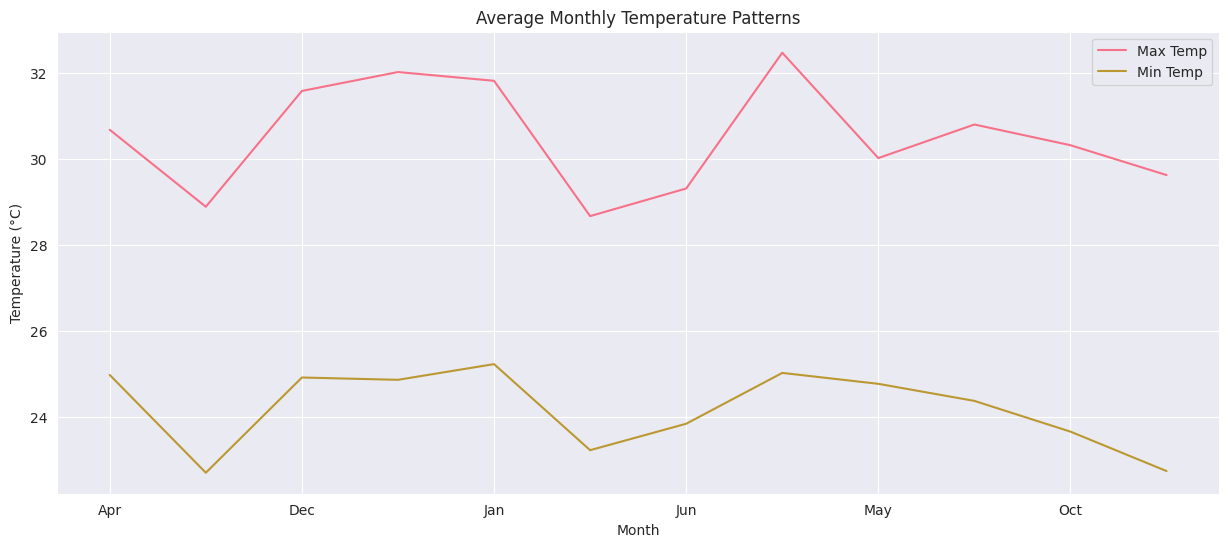

In [154]:

# Plot temperature trends
plt.figure(figsize=(15, 6))

# Max temperature by year
plt.subplot(1, 2, 1)
sns.boxplot(x='Year', y='Max Temperature', data=combined_max_temp_df)
plt.title('Max Temperature Distribution by Year')
plt.xticks(rotation=45)
plt.ylabel('Temperature (°C)')

# Min temperature by year
plt.subplot(1, 2, 2)
sns.boxplot(x='Year', y='Min Temperature', data=combined_min_temp_df)
plt.title('Min Temperature Distribution by Year')
plt.xticks(rotation=45)
plt.ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()

# Monthly temperature patterns
plt.figure(figsize=(15, 6))
combined_max_temp_df.groupby('Month')['Max Temperature'].mean().plot(label='Max Temp')
combined_min_temp_df.groupby('Month')['Min Temperature'].mean().plot(label='Min Temp')
plt.title('Average Monthly Temperature Patterns')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()


## 🧪 Standardizing & Merging Climate Data (Rainfall + Temperature)

---

### 📌 Step Objective:
To create a unified climate dataset by standardizing and merging **rainfall**, **maximum temperature**, and **minimum temperature** data into a single DataFrame for analysis and modeling.

---

### 🛠️ Standardizing Temperature DataFrames
- **Renamed `Station` → `Region`** for consistency across datasets.
- Removed unnecessary columns: `Station`, `District`.

```python
combined_max_temp_df["Region"] = combined_max_temp_df["Station"]
combined_max_temp_df.drop(["Station", "District"], axis=1, inplace=True)


In [155]:
# Standardize temperature data frames
combined_max_temp_df["Region"] = combined_max_temp_df["Station"]
combined_max_temp_df.drop(["Station", "District"], axis=1, inplace=True)

combined_min_temp_df["Region"] = combined_min_temp_df["Station"]
combined_min_temp_df.drop(["Station", "District"], axis=1, inplace=True)

# Define region mapping
PEMBA_DISTRICTS = ['WETE', 'MICHEWENI', 'CHAKE-CHAKE', 'MKOANI']
UNGUJA_DISTRICTS = ['MAGHARIBI  B', 'KUSINI', 'MJINI', 'KASKAZINI B', 'MAGHARIBI  A', 'KASKAZINI A', 'KATI']

def map_to_island(district):
    """Maps district name to broader region (Zanzibar/Pemba)."""
    if pd.isna(district):
        return 'Unknown'
    district_upper = district.upper()
    if district_upper in [d.upper() for d in UNGUJA_DISTRICTS]:
        return 'Unguja'
    elif district_upper in [d.upper() for d in PEMBA_DISTRICTS]:
        return 'Pemba'
    return 'Unknown'

# Apply region mapping to rainfall data
combined_rainfall_df['Island'] = combined_rainfall_df['District'].apply(map_to_island)

# Merge temperature data
temperature_combined_df = pd.merge(
    combined_max_temp_df,
    combined_min_temp_df,
    on=['Year', 'Month', 'Week'],
    how='outer'
)

# Final merge with rainfall data
climate_combined_df = pd.merge(
    combined_rainfall_df,
    temperature_combined_df,
    on=['Year', 'Month', 'Week'],
    how='left'
)

# Save final combined data
final_output_path = '../RawDataset/rainfall_temperature.csv'
climate_combined_df.to_csv(final_output_path, index=False)
print(f"\nSaved final combined climate data to {final_output_path}")

# Show final data structure
print("\nFinal combined data structure:")
climate_combined_df.info()
climate_combined_df.head()



Saved final combined climate data to ../RawDataset/rainfall_temperature.csv

Final combined data structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   District         10080 non-null  object 
 1   Station          10080 non-null  object 
 2   Year             10080 non-null  int64  
 3   Month            10080 non-null  object 
 4   Week             10080 non-null  object 
 5   Rainfall         9840 non-null   float64
 6   Island           10080 non-null  object 
 7   Max Temperature  10080 non-null  float64
 8   Region_x         10080 non-null  object 
 9   Min Temperature  10080 non-null  float64
 10  Region_y         10080 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 866.4+ KB


,District,Station,Year,Month,Week,Rainfall,Island,Max Temperature,Region_x,Min Temperature,Region_y
0,MAGHARIBI B,Zanzibar Airport,2023,Jan,1st week,3.8,Unguja,32.142857,Zanzibar,26.885714,Zanzibar
1,MAGHARIBI B,Zanzibar Airport,2023,Jan,1st week,3.8,Unguja,32.142857,Zanzibar,25.200000,Pemba
2,MAGHARIBI B,Zanzibar Airport,2023,Jan,1st week,3.8,Unguja,32.114286,Pemba,26.885714,Zanzibar
3,MAGHARIBI B,Zanzibar Airport,2023,Jan,1st week,3.8,Unguja,32.114286,Pemba,25.200000,Pemba
4,MAGHARIBI B,Zanzibar Airport,2023,Feb,1st week,0.0,Unguja,33.357143,Zanzibar,25.042857,Zanzibar


In [156]:
climate_combined_df['Island'].unique()

array(['Unguja', 'Pemba'], dtype=object)

### Combined Data Visualization

Visualizing relationships between rainfall and temperature across regions.

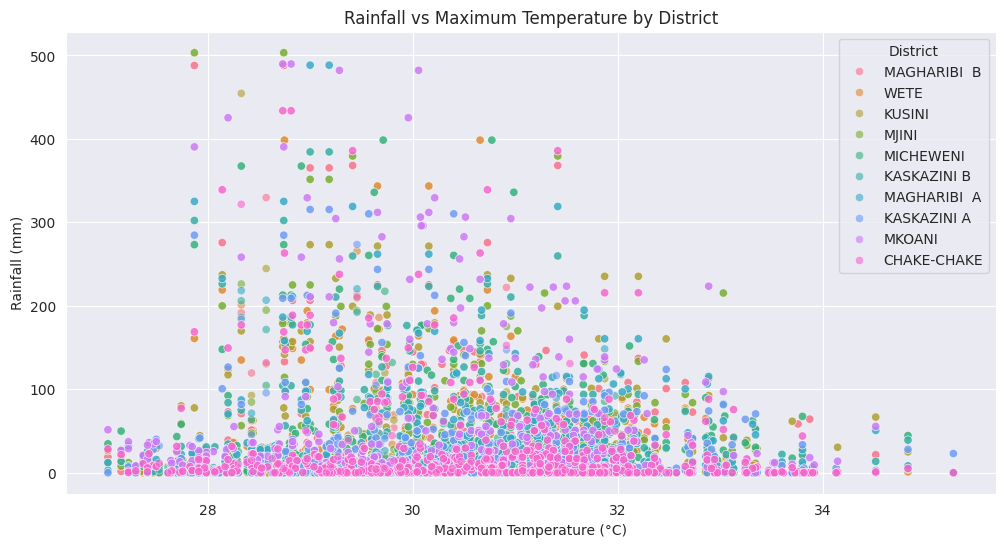

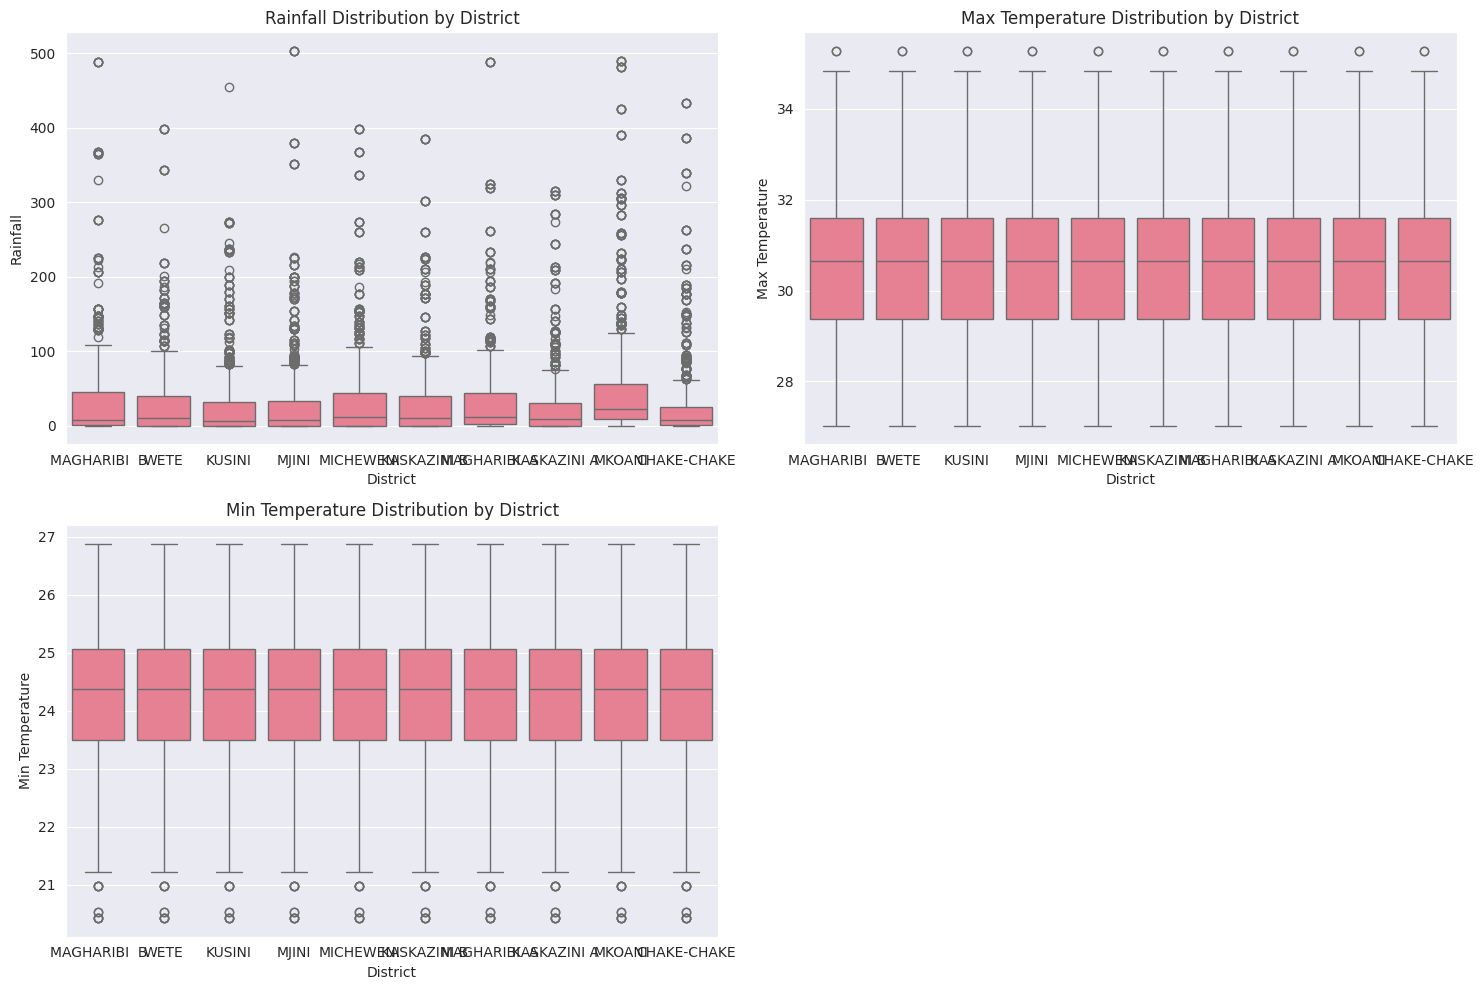

In [157]:

# Scatter plot of rainfall vs temperature
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='Max Temperature', 
    y='Rainfall', 
    hue='District', 
    data=climate_combined_df,
    alpha=0.6
)
plt.title('Rainfall vs Maximum Temperature by District')
plt.xlabel('Maximum Temperature (°C)')
plt.ylabel('Rainfall (mm)')
plt.show()

# Regional climate patterns
plt.figure(figsize=(15, 10))

# Rainfall by region
plt.subplot(2, 2, 1)
sns.boxplot(x='District', y='Rainfall', data=climate_combined_df)
plt.title('Rainfall Distribution by District')

# Max temp by region
plt.subplot(2, 2, 2)
sns.boxplot(x='District', y='Max Temperature', data=climate_combined_df)
plt.title('Max Temperature Distribution by District')

# Min temp by region
plt.subplot(2, 2, 3)
sns.boxplot(x='District', y='Min Temperature', data=climate_combined_df)
plt.title('Min Temperature Distribution by District')

plt.tight_layout()
plt.show()


# 🔍 Temperature Imputation for 2018 Using Linear Regression

This section addresses **missing temperature values for the year 2018** within our climate dataset. The aim is to estimate these values using historical data trends derived from previous years.

We utilize a **simple Linear Regression model** to make predictions for each `(District, Month, Week)` grouping. This localized and temporal approach ensures that regional and seasonal variations are preserved in the imputation process.

---

## 📌 Objective

Many 2018 entries for **maximum** and **minimum temperature** are missing or incomplete. To ensure the dataset is suitable for statistical modeling or machine learning applications, we must fill in these gaps responsibly.

Instead of relying on arbitrary interpolation or fixed averages, we:
- Group historical data by `District`, `Month`, and `Week`
- Fit a linear regression model for each group using past years (excluding 2018)
- Predict missing 2018 temperatures from the resulting model

---

## 🧩 Function: `predict_temperature(group_df, temperature_column)`

### ➤ Purpose

This function trains a **Linear Regression model** on a subset of the dataset to estimate either:
- `Max Temperature`
- `Min Temperature`

for the year 2018.

### ➤ Parameters

- `group_df`: Subset of the data containing rows for a specific district-month-week combination
- `temperature_column`: Column name (`'Max Temperature'` or `'Min Temperature'`) to be predicted

### ➤ Workflow

1. **Drop Missing Values**:
   Ensures the model is trained only on rows that contain valid temperature values.
   ```python
   clean_df = group_df.dropna(subset=[temperature_column])


In [158]:

def predict_temperature(group_df, temperature_column):
    """
    Predicts temperature for 2018 using linear regression on historical data.
    
    Returns:
    - Predicted temperature or None if insufficient data
    """
    clean_df = group_df.dropna(subset=[temperature_column])
    if clean_df['Year'].nunique() < 2:
        return None  # Not enough data points
    
    model = LinearRegression()
    X = clean_df['Year'].values.reshape(-1, 1)
    y = clean_df[temperature_column].values
    model.fit(X, y)
    return model.predict([[2018]])[0]

# Process each district-month-week combination
for (district, month, week), group in climate_combined_df.groupby(['District', 'Month', 'Week']):
    # Find 2018 records for this group
    mask_2018 = (
        (climate_combined_df['Year'] == 2018) &
        (climate_combined_df['District'] == district) &
        (climate_combined_df['Month'] == month) &
        (climate_combined_df['Week'] == week)
    )
    
    if mask_2018.any():
        # Get historical data (excluding 2018)
        historical_data = climate_combined_df[
            (climate_combined_df['District'] == district) &
            (climate_combined_df['Month'] == month) &
            (climate_combined_df['Week'] == week) &
            (climate_combined_df['Year'] != 2018)
        ]
        
        # Predict missing values
        predicted_max = predict_temperature(historical_data, 'Max Temperature')
        predicted_min = predict_temperature(historical_data, 'Min Temperature')
        
        # Update DataFrame
        if predicted_max is not None:
            climate_combined_df.loc[mask_2018, 'Max Temperature'] = predicted_max
        if predicted_min is not None:
            climate_combined_df.loc[mask_2018, 'Min Temperature'] = predicted_min

print("Completed missing value imputation for 2018 data.")


Completed missing value imputation for 2018 data.



### Missing Data Analysis

Visualizing the impact of our missing value imputation.


Missing values in 2018 data:
- Before imputation: Max Temp - 0, Min Temp - 0
- After imputation: Max Temp - 0, Min Temp - 0


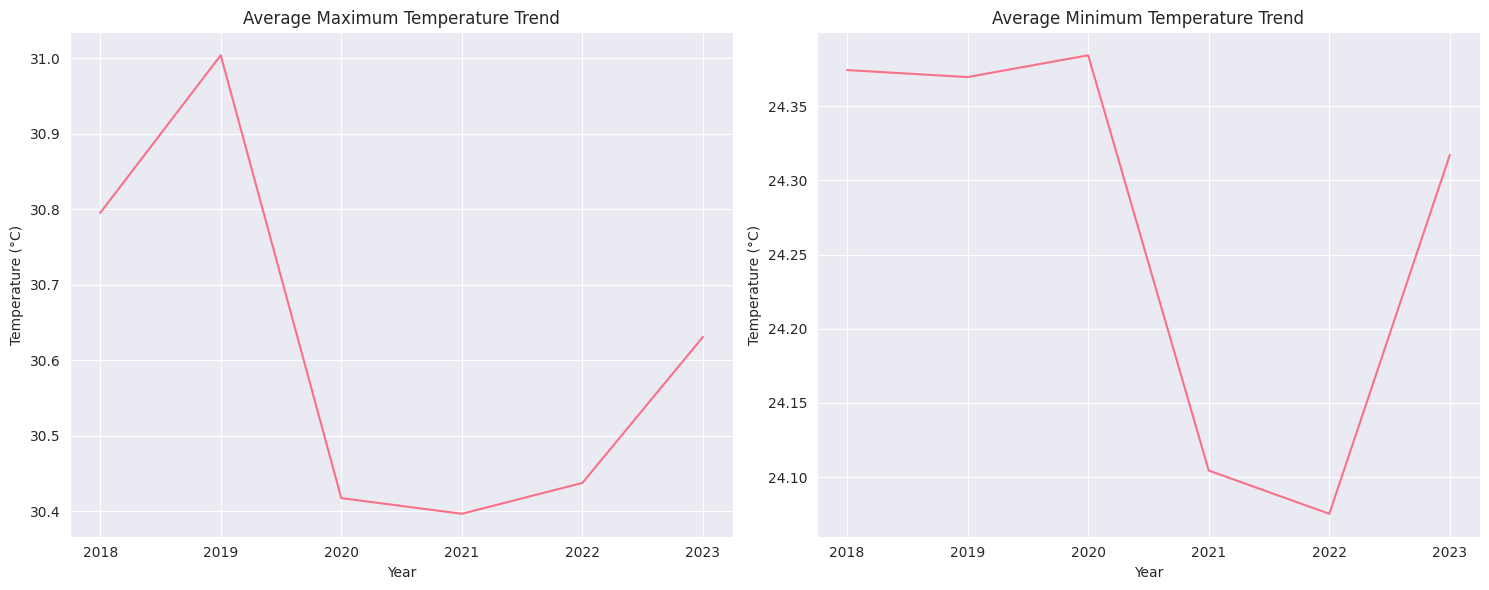

In [159]:

# Before and after missing value counts
missing_before = climate_combined_df[climate_combined_df['Year'] == 2018][
    ['Max Temperature', 'Min Temperature']
].isna().sum()

missing_after = climate_combined_df[climate_combined_df['Year'] == 2018][
    ['Max Temperature', 'Min Temperature']
].isna().sum()

print("Missing values in 2018 data:")
print(f"- Before imputation: Max Temp - {missing_before['Max Temperature']}, Min Temp - {missing_before['Min Temperature']}")
print(f"- After imputation: Max Temp - {missing_after['Max Temperature']}, Min Temp - {missing_after['Min Temperature']}")

# Plot temperature trends including imputed values
plt.figure(figsize=(15, 6))

# Max temperature trend
plt.subplot(1, 2, 1)
climate_combined_df.groupby('Year')['Max Temperature'].mean().plot()
plt.title('Average Maximum Temperature Trend')
plt.ylabel('Temperature (°C)')

# Min temperature trend
plt.subplot(1, 2, 2)
climate_combined_df.groupby('Year')['Min Temperature'].mean().plot()
plt.title('Average Minimum Temperature Trend')
plt.ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()



## Step 6: Final Data Export and Summary
> Saved the final processed climatic data in `../ProcessedData/final_climate_data.csv`
The cleaned and processed data is now ready for analysis.


In [160]:

# Final data summary
print("\nFinal dataset summary:")
print(f"- Total records: {len(climate_combined_df)}")
print(f"- Time period: {climate_combined_df['Year'].min()} to {climate_combined_df['Year'].max()}")
print(f"- Regions: {climate_combined_df['Island'].unique().tolist()}")
print("\nData types:")
climate_combined_df.dtypes

# Save final processed data
final_processed_path = '../ProcessedData/final_climate_data.csv'
climate_combined_df.to_csv(final_processed_path, index=False)
print(f"\nSaved final processed data to {final_processed_path}")



Final dataset summary:
- Total records: 10080
- Time period: 2018 to 2023
- Regions: ['Unguja', 'Pemba']

Data types:

Saved final processed data to ../ProcessedData/final_climate_data.csv


## Key Findings and Insights

1. **Data Distribution**:
   - Rainfall patterns show clear seasonal variations
   - Temperature ranges vary significantly between regions

2. **Data Quality**:
   - Successfully handled missing 2018 data using regression
   - Standardized measurements across different source files

3. **Regional Differences**:
   - Zanzibar and Pemba show distinct climate patterns
   - Temperature extremes vary by region

The processed dataset is now ready for more advanced analysis and modeling.



##  Incorporating Additional Datasets

We'll now enhance our climate data with:
1. Mosquito net distribution data (yearly)
2. Geographic coordinates (by district)
3. Humidity data (monthly, to be normalized to daily)


In [161]:

# Load additional datasets
mosquito_nets_df = pd.read_excel('../RawDataset/treated_mosquito_net_distribution.xlsx')
district_coordinates_df = pd.read_csv("../RawDataset/sst_coord.csv")

print("Mosquito net distribution data sample:")
print(mosquito_nets_df.head())

print("\nDistrict coordinates data sample:")
print(district_coordinates_df.head())


Mosquito net distribution data sample:
   Year  Net distribution
0  2018          178072.0
1  2019          222374.0
2  2020          415012.0
3  2021          878264.0
4  2022               NaN

District coordinates data sample:
      District  LONGITUDE  LATITUDE
0  KASKAZINI A      39.29     -5.72
1  KASKAZINI B      39.40     -5.98
2       KUSINI      39.58     -6.32
3  MAGHARIBI A      39.21     -6.10
4  MAGHARIBI B      39.18     -6.23


In [162]:

mosquito_nets_df["Net distribution"] = mosquito_nets_df["Net distribution"].fillna(
    mosquito_nets_df["Net distribution"].mean()
)



### Visualizing Additional Data

Let's examine the distribution of these new datasets before merging.


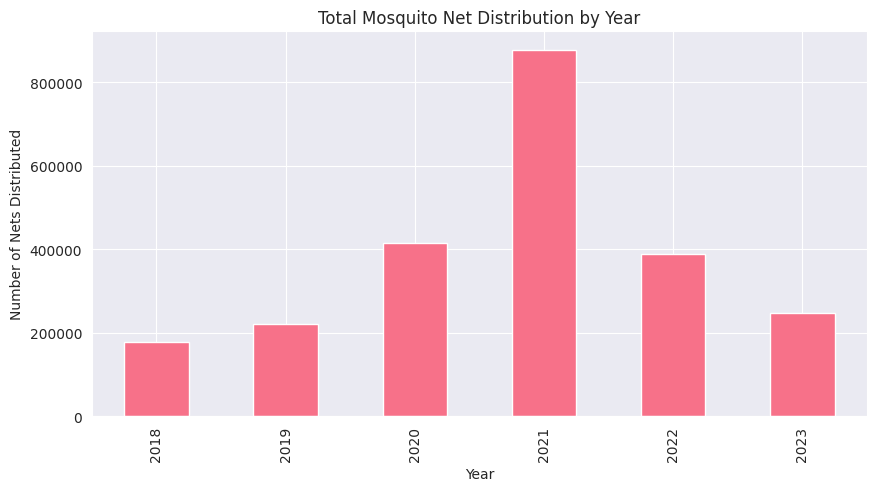

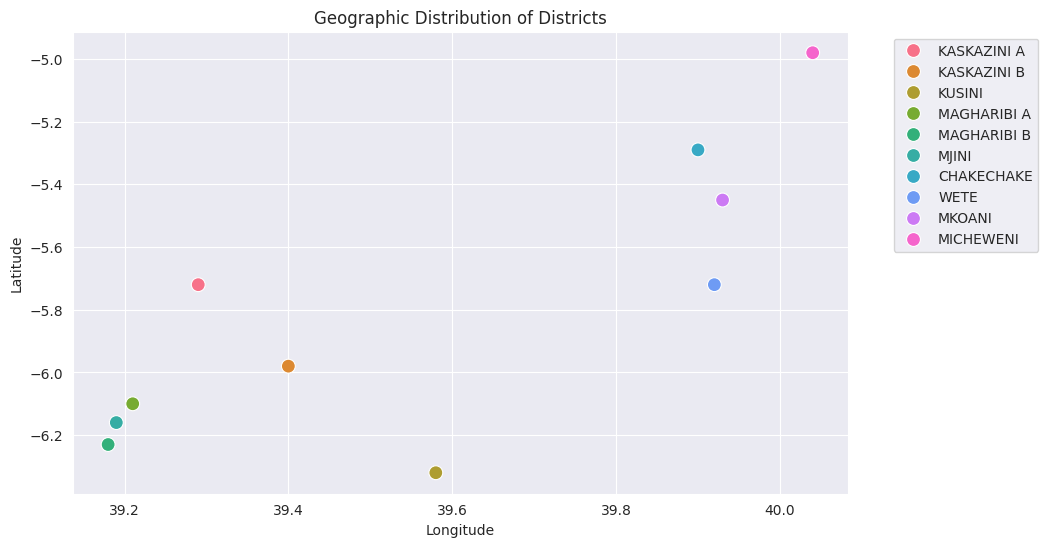

In [163]:

# Plot mosquito net distribution over years
plt.figure(figsize=(10, 5))
mosquito_nets_df.groupby('Year')['Net distribution'].sum().plot(kind='bar')
plt.title('Total Mosquito Net Distribution by Year')
plt.ylabel('Number of Nets Distributed')
plt.show()

# Plot district coordinates
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='LONGITUDE', 
    y='LATITUDE', 
    data=district_coordinates_df,
    hue='District',
    s=100
)
plt.title('Geographic Distribution of Districts')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



##  Merging Additional Data with Climate Data

We'll merge:
1. Mosquito net data by year
2. District coordinates by district name


In [164]:

# First merge: Add mosquito net distribution by year
climate_with_nets_df = pd.merge(
    climate_combined_df,
    mosquito_nets_df,
    on=['Year'],
    how='left'
)

# Second merge: Add district coordinates
climate_with_geo_df = pd.merge(
    climate_with_nets_df,
    district_coordinates_df,
    on=['District'],
    how='left'
)

# Clean up column names and formats
climate_with_geo_df['Week'] = climate_with_geo_df['Week'].str.strip()
climate_with_geo_df['Month'] = climate_with_geo_df['Month'].str.strip()

print("\nData after merging additional datasets:")
climate_with_geo_df.info()
climate_with_geo_df.head()



Data after merging additional datasets:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   District          10080 non-null  object 
 1   Station           10080 non-null  object 
 2   Year              10080 non-null  int64  
 3   Month             10080 non-null  object 
 4   Week              10080 non-null  object 
 5   Rainfall          9840 non-null   float64
 6   Island            10080 non-null  object 
 7   Max Temperature   10080 non-null  float64
 8   Region_x          10080 non-null  object 
 9   Min Temperature   10080 non-null  float64
 10  Region_y          10080 non-null  object 
 11  Net distribution  10080 non-null  float64
 12  LONGITUDE         7056 non-null   float64
 13  LATITUDE          7056 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 1.1+ MB


,District,Station,Year,Month,Week,Rainfall,Island,Max Temperature,Region_x,Min Temperature,Region_y,Net distribution,LONGITUDE,LATITUDE
0,MAGHARIBI B,Zanzibar Airport,2023,Jan,1st week,3.8,Unguja,32.142857,Zanzibar,26.885714,Zanzibar,248000.0,NaN,NaN
1,MAGHARIBI B,Zanzibar Airport,2023,Jan,1st week,3.8,Unguja,32.142857,Zanzibar,25.200000,Pemba,248000.0,NaN,NaN
2,MAGHARIBI B,Zanzibar Airport,2023,Jan,1st week,3.8,Unguja,32.114286,Pemba,26.885714,Zanzibar,248000.0,NaN,NaN
3,MAGHARIBI B,Zanzibar Airport,2023,Jan,1st week,3.8,Unguja,32.114286,Pemba,25.200000,Pemba,248000.0,NaN,NaN
4,MAGHARIBI B,Zanzibar Airport,2023,Feb,1st week,0.0,Unguja,33.357143,Zanzibar,25.042857,Zanzibar,248000.0,NaN,NaN


# 🌦️ Generating Realistic Daily Climate Data from Weekly Aggregates

This notebook section transforms **weekly climate observations** into **simulated daily records** for more granular analysis. The process respects the original climate patterns and statistical characteristics while providing day-level resolution.

---

## 📌 Objective

The original dataset provides **weekly aggregates** for:
- Rainfall
- Maximum Temperature
- Minimum Temperature

To support downstream applications such as:
- Climate trend analysis
- Daily forecasting models
- Agricultural planning

...we synthesize **daily-level data** that reflects the variability within each week.

---

## 🗓️ Step 1: Month and Week Mapping

### 🔢 Month Number Mapping

```python
month_to_num = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
climate_with_geo_df['Month_num'] = climate_with_geo_df['Month'].map(month_to_num)


In [165]:

# Create month number mapping
month_to_num = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
climate_with_geo_df['Month_num'] = climate_with_geo_df['Month'].map(month_to_num)

# Week order for proper sorting
week_order_mapping = {
    '1st week': 1,
    '2nd week': 2,
    '3rd week': 3,
    '4th week': 4,
    '5th week': 5
}

# Initialize list for daily records
daily_climate_records = []

# Process each station-year-month group
for (station, year, month), group in climate_with_geo_df.groupby(['Station', 'Year', 'Month_num']):
    
    # Get month info
    days_in_month = pd.Timestamp(year=year, month=month, day=1).days_in_month
    month_start = pd.Timestamp(year=year, month=month, day=1)
    num_weeks = len(group)
    
    # Distribute days across weeks
    base_days = days_in_month // num_weeks
    extra_days = days_in_month % num_weeks
    days_per_week = [base_days + (1 if i < extra_days else 0) for i in range(num_weeks)]
    
    current_day = 0
    for week_idx, (_, weekly_data) in enumerate(group.iterrows()):
        week_days = days_per_week[week_idx]
        
        # Create daily variations with realistic distributions
        daily_rainfall = np.clip(
            np.random.normal(
                loc=weekly_data['Rainfall'] / week_days,
                scale=weekly_data['Rainfall'] * 0.1 / week_days,
                size=week_days
            ),
            0, None  # Ensure no negative rainfall
        )
        
        daily_max_temp = np.random.normal(
            loc=weekly_data['Max Temperature'],
            scale=0.5,  # Small variation for temperature
            size=week_days
        )
        
        daily_min_temp = np.random.normal(
            loc=weekly_data['Min Temperature'],
            scale=0.5,
            size=week_days
        )
        
        # Create daily records
        for day_idx in range(week_days):
            record_date = month_start + pd.Timedelta(days=current_day)
            current_day += 1
            
            daily_climate_records.append({
                'District': weekly_data['District'],
                'Station': weekly_data['Station'],
                'Island': weekly_data['Island'],
                'Net_distribution': weekly_data.get('Net distribution', np.nan),
                'Longitude': weekly_data.get('LONGITUDE', np.nan),
                'Latitude': weekly_data.get('LATITUDE', np.nan),
                'Date': record_date.strftime("%Y-%m-%d"),
                'Rainfall': round(daily_rainfall[day_idx], 2),
                'Max_temperature': round(daily_max_temp[day_idx], 2),
                'Min_temperature': round(daily_min_temp[day_idx], 2)
            })

# Create final daily DataFrame
daily_climate_df = pd.DataFrame(daily_climate_records)
daily_climate_df.sort_values(by=["Station", "Date"], inplace=True)

# Save to CSV
daily_climate_df.to_csv("processed_daily_climate_data.csv", index=False)
print(f"Daily climate data generated. Records: {len(daily_climate_df)}")

# Show sample
daily_climate_df.head()


Daily climate data generated. Records: 21910


,District,Station,Island,Net_distribution,Longitude,Latitude,Date,Rainfall,Max_temperature,Min_temperature
0,MKOANI,Abdalla mzee-Mkoani,Pemba,178072.0,39.93,-5.45,2018-01-01,NaN,33.05,27.08
1,MKOANI,Abdalla mzee-Mkoani,Pemba,178072.0,39.93,-5.45,2018-01-02,NaN,32.49,25.12
2,MKOANI,Abdalla mzee-Mkoani,Pemba,178072.0,39.93,-5.45,2018-01-03,NaN,33.57,25.55
3,MKOANI,Abdalla mzee-Mkoani,Pemba,178072.0,39.93,-5.45,2018-01-04,NaN,32.70,25.18
4,MKOANI,Abdalla mzee-Mkoani,Pemba,178072.0,39.93,-5.45,2018-01-05,NaN,32.76,25.95



### Daily Data Visualization

Let's examine the characteristics of our generated daily data.


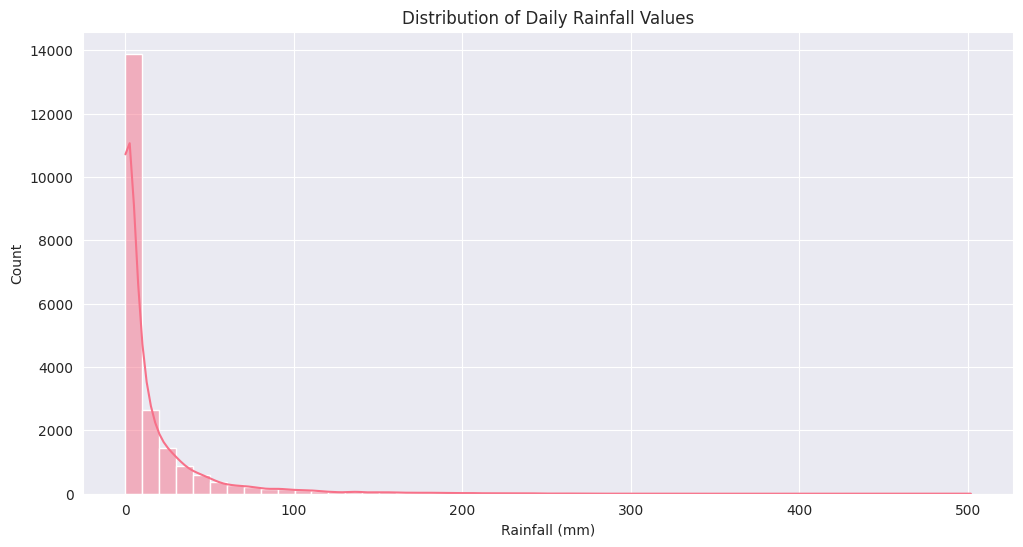

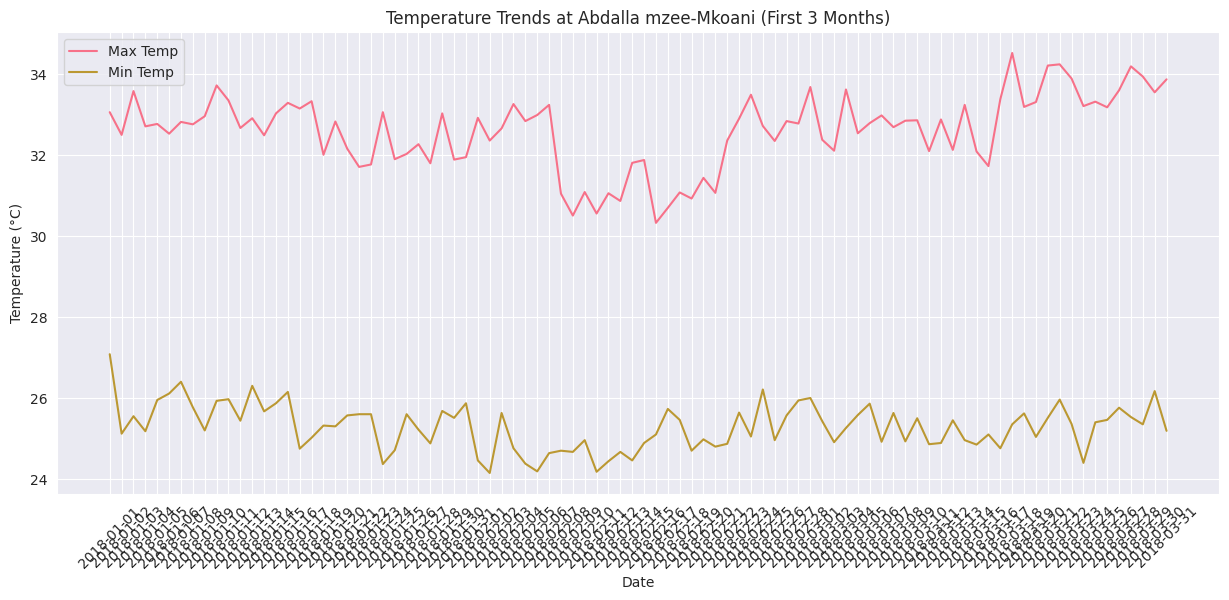

In [166]:

# Plot daily rainfall distribution
plt.figure(figsize=(12, 6))
sns.histplot(daily_climate_df['Rainfall'], bins=50, kde=True)
plt.title('Distribution of Daily Rainfall Values')
plt.xlabel('Rainfall (mm)')
plt.show()

# Plot temperature ranges over time
sample_station = daily_climate_df['Station'].iloc[0]
station_data = daily_climate_df[daily_climate_df['Station'] == sample_station].iloc[:90]  # First 3 months

plt.figure(figsize=(15, 6))
plt.plot(station_data['Date'], station_data['Max_temperature'], label='Max Temp')
plt.plot(station_data['Date'], station_data['Min_temperature'], label='Min Temp')
plt.title(f'Temperature Trends at {sample_station} (First 3 Months)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.legend()
plt.show()


---

### 📊 Processing Monthly Humidity Data into Daily Estimates

This section handles the conversion of monthly humidity data into daily values with realistic variations. It consists of the following steps:

1. **Function `process_humidity_data(file_path)`**

   * Reads a CSV file containing monthly humidity data.
   * Maps month names (e.g., 'JAN', 'FEB') to numeric values.
   * For each record, it generates daily humidity estimates using a normal distribution centered around the monthly average.
   * Ensures all humidity values fall within a valid range (0–100%).
   * Returns a DataFrame of daily records with columns: `District`, `Date`, and `Humidity`.

2. **Batch Processing All Humidity CSV Files**

   * Iterates over all CSV files in the `../RawDataset/humidity` folder.
   * Applies the `process_humidity_data` function to each file.
   * Combines all the daily estimates into a single DataFrame.

3. **Saving and Enhancing the Data**

   * Saves the combined humidity data to `combined_humidity.csv`.
   * Adds an `Island` column by mapping districts to either "Pemba" or "Unguja".
   * Groups the data by `Island` and `Date` to compute average humidity per island per day.

This preprocessing is essential for integrating humidity data with daily climate records and supporting further regional analysis.

---

In [173]:

def process_humidity_data(file_path):
    """
    Converts monthly humidity data to daily estimates with realistic variations.
    
    Parameters:
    - file_path: Path to CSV file containing monthly humidity data
    
    Returns:
    - DataFrame with daily humidity estimates
    """
    # Load and prepare data
    humidity_df = pd.read_csv(file_path)
    print(humidity_df.head())
    # Load and prepare data
    print(f"\nColumns in {file_path}: {humidity_df.columns.tolist()}")
    print(humidity_df.head())

    # Month name mapping
    month_name_to_num = {
        'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4,
        'MAY': 5, 'JUN': 6, 'JUL': 7, 'AUG': 8,
        'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
    }
    humidity_df['Month_num'] = humidity_df['Month'].map(month_name_to_num)
    
    # Process each monthly record
    daily_humidity_records = []
    
    for _, row in humidity_df.iterrows():
        year = int(row['Year'])
        month = int(row['Month_num'])
        region = row['Region']
        monthly_humidity = float(row['Value'])
        
        # Create daily values with realistic variation
        days_in_month = pd.Timestamp(year, month, 1).days_in_month
        daily_humidity = np.random.normal(
            loc=monthly_humidity,
            scale=1.5,  # Small variation for humidity
            size=days_in_month
        )
        daily_humidity = np.clip(daily_humidity, 0, 100)  # Valid humidity range
        
        # Create daily records
        for day in range(1, days_in_month + 1):
            record_date = datetime.datetime(year, month, day).strftime("%Y-%m-%d")
            daily_humidity_records.append({
                'District': region,  # Will match with district in main DF
                'Date': record_date,
                'Humidity': round(daily_humidity[day - 1], 1)
            })
    
    return pd.DataFrame(daily_humidity_records)

# Process all humidity files
humidity_folder = '../RawDataset/humidity'
all_humidity_data = []

print("Processing humidity data files:")
for filename in os.listdir(humidity_folder):
    if filename.endswith('.csv'):
        file_path = os.path.join(humidity_folder, filename)
        print(f"- {filename}")
        humidity_df = process_humidity_data(file_path)
        all_humidity_data.append(humidity_df)

# Combine all humidity data
combined_humidity_df = pd.concat(all_humidity_data, ignore_index=True)
combined_humidity_df.sort_values(by=["District", "Date"], inplace=True)

combined_humidity_df.to_csv("../RawDataset/combined_humidity.csv", index=False)
print("\nProcessed humidity data sample:")
print(combined_humidity_df.shape)

# Function to assign island
def get_island(district):
    if district in PEMBA_DISTRICTS:
        return 'Pemba'
    elif district in UNGUJA_DISTRICTS:
        return 'Unguja'
    else:
        return 'UNKNOWN'

# Add Island column
combined_humidity_df['Island'] = combined_humidity_df['District'].apply(get_island)

# Group by Island and Date, then calculate average humidity
island_humidity_df = combined_humidity_df.groupby(['Island', 'Date'])['Humidity'].mean().reset_index()

# View result
print(island_humidity_df.head())

Processing humidity data files:
- humidity_magharibi_a.csv
         Region  Year Month  Value
0  MAGHARIBI  A  2018   JAN     71
1  MAGHARIBI  A  2019   JAN     68
2  MAGHARIBI  A  2020   JAN     81
3  MAGHARIBI  A  2021   JAN     77
4  MAGHARIBI  A  2022   JAN     80

Columns in ../RawDataset/humidity/humidity_magharibi_a.csv: ['Region', 'Year', 'Month', 'Value']
         Region  Year Month  Value
0  MAGHARIBI  A  2018   JAN     71
1  MAGHARIBI  A  2019   JAN     68
2  MAGHARIBI  A  2020   JAN     81
3  MAGHARIBI  A  2021   JAN     77
4  MAGHARIBI  A  2022   JAN     80
- pemba_humidity.csv
        Region  Year Month  Value
0  CHAKE-CHAKE  2018   JAN   90.0
1  CHAKE-CHAKE  2019   JAN   89.0
2  CHAKE-CHAKE  2020   JAN   86.0
3  CHAKE-CHAKE  2021   JAN   90.0
4  CHAKE-CHAKE  2022   JAN   76.0

Columns in ../RawDataset/humidity/pemba_humidity.csv: ['Region', 'Year', 'Month', 'Value']
        Region  Year Month  Value
0  CHAKE-CHAKE  2018   JAN   90.0
1  CHAKE-CHAKE  2019   JAN   89.0
2  C


### Humidity Data Visualization

Examining the distribution and patterns in our humidity data.


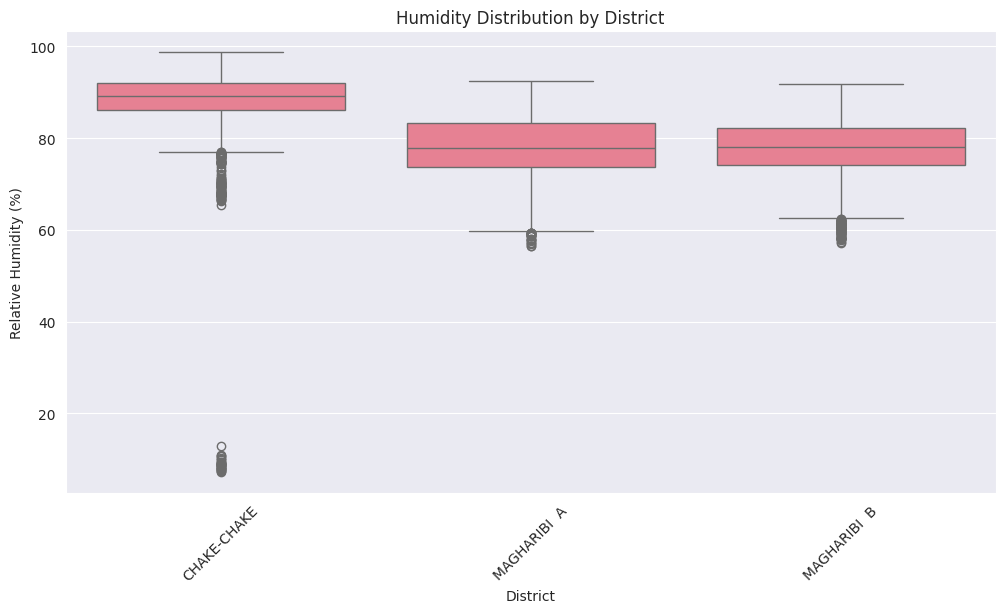

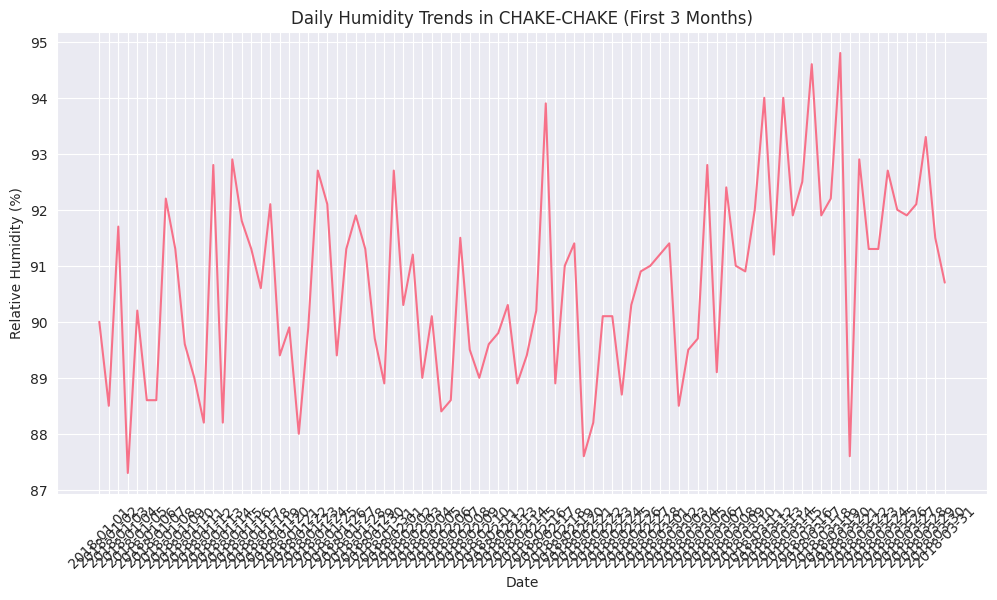

In [174]:

# Plot humidity distribution by region
plt.figure(figsize=(12, 6))
sns.boxplot(x='District', y='Humidity', data=combined_humidity_df)
plt.title('Humidity Distribution by District')
plt.xticks(rotation=45)
plt.ylabel('Relative Humidity (%)')
plt.show()

# Plot temporal trends
sample_district = combined_humidity_df['District'].iloc[0]
district_humidity = combined_humidity_df[
    combined_humidity_df['District'] == sample_district
].iloc[:90]  # First 3 months

plt.figure(figsize=(12, 6))
plt.plot(district_humidity['Date'], district_humidity['Humidity'])
plt.title(f'Daily Humidity Trends in {sample_district} (First 3 Months)')
plt.xlabel('Date')
plt.ylabel('Relative Humidity (%)')
plt.xticks(rotation=45)
plt.show()


In [175]:
daily_climate_df.isna().sum()

District               0
Station                0
Island                 0
Net_distribution       0
Longitude           6573
Latitude            6573
Date                   0
Rainfall             730
Max_temperature        0
Min_temperature        0
dtype: int64

In [176]:
island_humidity_df.isna().sum()

Island      0
Date        0
Humidity    0
dtype: int64

In [177]:
daily_climate_df["Island"].unique()

array(['Pemba', 'Unguja'], dtype=object)


## Final Data Integration

> adding the humidity to the climatic data

### thid bring about the combined dataset with the climatic data including the humidity


In [178]:

# Merge humidity data with daily climate data
final_daily_climate_df = pd.merge(
    daily_climate_df,
    island_humidity_df,
    on=['Date', 'Island'],
    how='left'
)

# Final cleaning and verification
final_daily_climate_df.dropna(subset=['Rainfall', 'Max_temperature', 'Min_temperature'], inplace=True)

print("\nFinal dataset information:")
final_daily_climate_df.info()
final_daily_climate_df.head()

# Save final dataset
final_output_path = "final_daily_climate_with_humidity.csv"
final_daily_climate_df.to_csv(final_output_path, index=False)
print(f"\nSaved final daily climate data to {final_output_path}")
print(final_daily_climate_df.head())


Final dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 21180 entries, 730 to 21909
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   District          21180 non-null  object 
 1   Station           21180 non-null  object 
 2   Island            21180 non-null  object 
 3   Net_distribution  21180 non-null  float64
 4   Longitude         14607 non-null  float64
 5   Latitude          14607 non-null  float64
 6   Date              21180 non-null  object 
 7   Rainfall          21180 non-null  float64
 8   Max_temperature   21180 non-null  float64
 9   Min_temperature   21180 non-null  float64
 10  Humidity          21180 non-null  float64
dtypes: float64(7), object(4)
memory usage: 1.9+ MB

Saved final daily climate data to final_daily_climate_with_humidity.csv
    District              Station Island  Net_distribution  Longitude  \
730   MKOANI  Abdalla mzee-Mkoani  Pemba          415012.


##  Comprehensive Data Visualization

Final visualizations showing relationships between all climate variables.


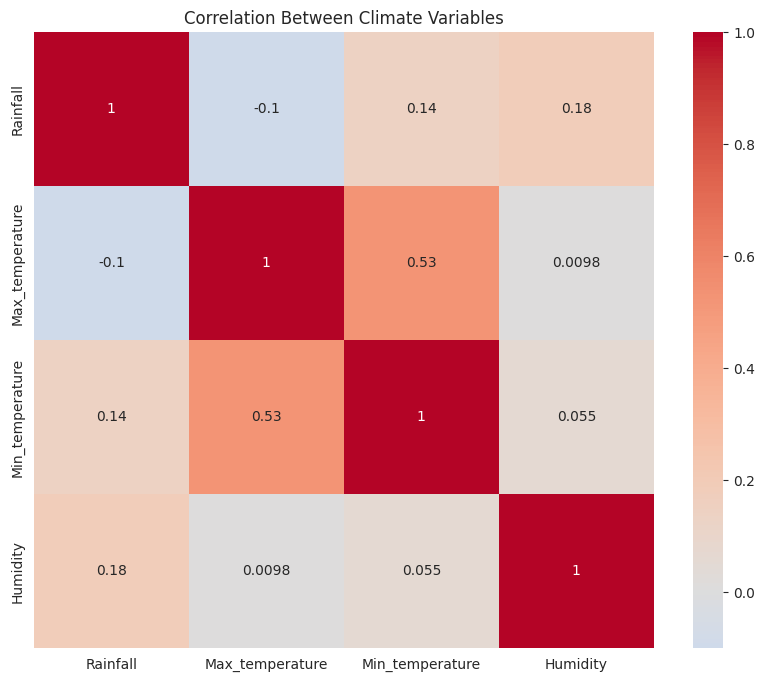

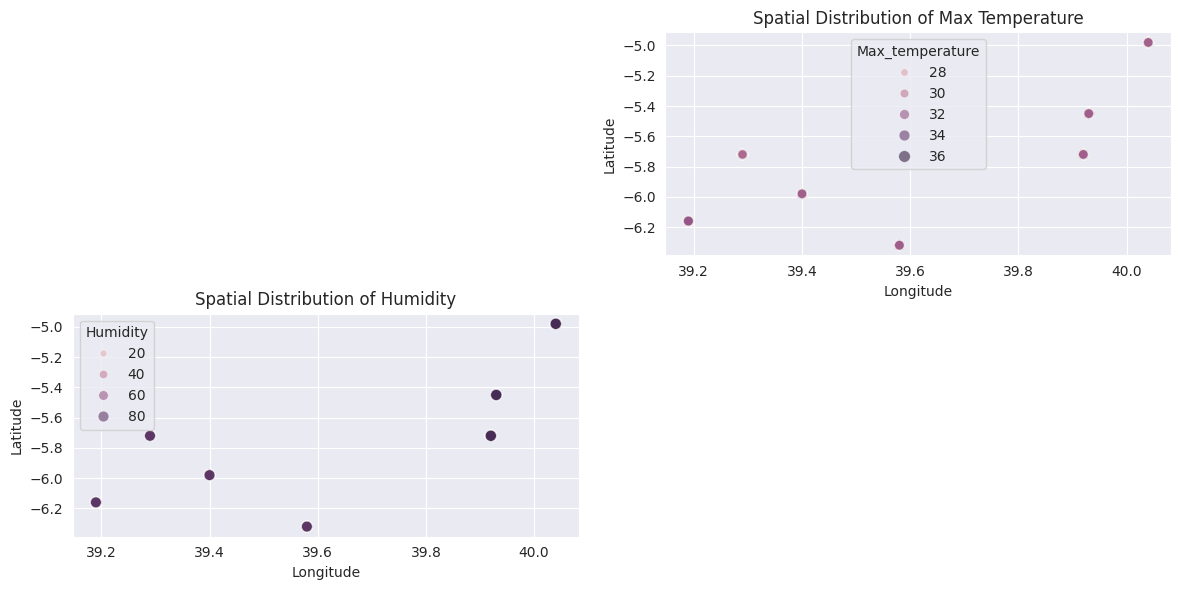

In [179]:

# Correlation matrix of climate variables
plt.figure(figsize=(10, 8))
corr_matrix = final_daily_climate_df[[
    'Rainfall', 'Max_temperature', 'Min_temperature', 'Humidity'
]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Climate Variables')
plt.show()


# Max Temperature
plt.subplot(2, 2, 2)
sns.scatterplot(
    x='Longitude', 
    y='Latitude', 
    size='Max_temperature',
    hue='Max_temperature',
    data=final_daily_climate_df,
    alpha=0.6
)
plt.title('Spatial Distribution of Max Temperature')

# Humidity
plt.subplot(2, 2, 3)
sns.scatterplot(
    x='Longitude', 
    y='Latitude', 
    size='Humidity',
    hue='Humidity',
    data=final_daily_climate_df,
    alpha=0.6
)
plt.title('Spatial Distribution of Humidity')

plt.tight_layout()
plt.show()


---

### 🏥 Loading and Standardizing Patient Clinical Data with Malaria Test Results

This code cell focuses on preparing the patient clinical dataset to ensure consistency and usability for further analysis, particularly in merging with climate data:

1. **Loading Patient Data**

   * Reads patient clinical data from an Excel file containing detailed malaria test results.

2. **Initial District Name Inspection**

   * Prints unique district names from the patient dataset to identify inconsistencies or variations compared to the climate dataset.

3. **District Name Standardization**

   * Defines a dictionary to correct district names, ensuring they match the climate dataset naming conventions.
   * Adjustments include:

     * Correcting hyphen inconsistencies (e.g., "CHAKECHAKE" to "CHAKE-CHAKE")
     * Matching spacing differences (e.g., "MAGHARIBI A" to "MAGHARIBI  A" with double spaces)
     * Confirming unchanged names explicitly for clarity.

4. **Applying Standardization Pipeline**

   * Converts all district names to uppercase for case consistency.
   * Applies the corrections from the dictionary.
   * Strips leading/trailing whitespace and normalizes internal spacing.

5. **Verification**

   * Prints the unique standardized district names to confirm successful cleaning.

6. **Date Preparation**

   * Renames the malaria test date column to a uniform name "Date".
   * Converts this column to datetime format for proper time-based operations.
   * Sorts the dataframe chronologically by the date of malaria results.

7. **Summary Information**

   * Outputs dataframe info to verify data types, non-null counts, and overall structure.

This standardization is critical for accurate data integration and analysis, especially when combining clinical and environmental datasets by district and date.

---


In [180]:

# Load patient clinical data with detailed malaria test results
malaria_patients_df = pd.read_excel("../RawDataset/patient.xlsx")

# Standardize district naming to match our climate dataset
print("Initial district names in patient data:")
print(malaria_patients_df["Household District"].unique())

# Create comprehensive district name mapping
district_name_corrections = {
    # Standardize variations to match climate dataset
    "CHAKECHAKE": "CHAKE-CHAKE",  # Remove hyphen inconsistency
    "MAGHARIBI A": "MAGHARIBI  A",  # Match double space format
    "MAGHARIBI B": "MAGHARIBI  B",  # Match double space format
    "MICHEWENI": "MICHEWENI",       # Explicit confirmation
    "WETE": "WETE"                   # Explicit confirmation
}

# Apply standardization pipeline
malaria_patients_df = malaria_patients_df.rename(columns={"Household District": "District"})
malaria_patients_df["District"] = (
    malaria_patients_df["District"]
    .str.upper()  # Ensure case consistency
    .replace(district_name_corrections)  # Apply name corrections
    .str.strip()  # Remove leading/trailing whitespace
    .replace(r"\s{2,}", " ", regex=True)  # Standardize internal spacing
)

# Verify standardization
print("\nStandardized district names:")
print(malaria_patients_df["District"].unique())

# Prepare date field for merging
malaria_patients_df = malaria_patients_df.rename(columns={"Date Of Malaria Results": "Date"})
malaria_patients_df["Date"] = pd.to_datetime(malaria_patients_df["Date"], format="%Y-%m-%d")
malaria_patients_df = malaria_patients_df.sort_values(by='Date')
malaria_patients_df.info()

Initial district names in patient data:
['MJINI' 'KATI' 'KASKAZINI A' 'WETE' 'MAGHARIBI A' 'KASKAZINI B' 'KUSINI'
 'MAGHARIBI B' 'CHAKECHAKE' 'MKOANI' 'MICHEWENI' nan]

Standardized district names:
['MJINI' 'KATI' 'KASKAZINI A' 'WETE' 'MAGHARIBI A' 'KASKAZINI B' 'KUSINI'
 'MAGHARIBI B' 'CHAKE-CHAKE' 'MKOANI' 'MICHEWENI' nan]
<class 'pandas.core.frame.DataFrame'>
Index: 152559 entries, 4963 to 121121
Data columns (total 21 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Sn                              152559 non-null  object        
 1   Malaria Case ID                 151967 non-null  object        
 2   Household Island                152523 non-null  object        
 3   District                        152525 non-null  object        
 4   Household Shehia                152519 non-null  object        
 5   Date                            152559 non-null  datetime64[ns]
 6   Week   

In [181]:
malaria_patients_df.nunique()

Sn                                144517
Malaria Case ID                    54644
Household Island                       2
District                              11
Household Shehia                     451
Date                                2188
Week                                  53
Month                                 12
Year                                   6
Malaria Positive                       2
Travel History                         2
Sex                                    2
Age In Years                         232
AgeGroupLabel                          5
Household Member Type                  4
Facility                             351
Facility District                     19
Facility Type                          2
Household Location - Latitude      34060
Household Location - Longitude     32943
Occupation                            11
dtype: int64

---

### 🧹 Data Cleaning and Missing Value Imputation for Patient Clinical Data

This cell performs systematic handling of missing values in the malaria patient dataset to prepare it for robust analysis:

#### Step 1: Impute Missing Values in Categorical Columns

* **Target Columns:** Includes key categorical features such as `District`, `Household Island`, `Sex`, `Travel History`, `Occupation`, and health facility-related fields.
* **Imputation Strategy:** Replace missing (`NaN`) values with the **mode** (most frequent value) of each respective column.
* **Rationale:** Using the mode preserves the most common category, minimizing bias while filling gaps in categorical data.

#### Step 2: Impute Missing Numeric Data (Age)

* **Target Column:** `Age In Years` (numeric).
* **Imputation Strategy:** Fill missing values with the **median** age.
* **Rationale:** The median is a robust measure of central tendency that is less sensitive to outliers than the mean, providing a stable estimate for missing age values.

#### Step 3: Handle Missing Geographic Coordinates

* **Target Columns:** Latitude and Longitude of patient household locations.
* **Imputation Strategy:** Replace missing values with the **mean** of the respective columns.
* **Alternative Option:** These columns could be dropped if geographic coordinates are not required for the analysis.
* **Rationale:** Using the mean retains approximate location information while handling missing spatial data points.

#### Optional Step: Fill Missing Identifiers

* **Target Column:** `Malaria Case ID`.
* **Imputation Strategy:** Fill missing IDs with a placeholder string like `"UNKNOWN_CASE"`.
* **Purpose:** Ensures no missing entries exist for unique case identifiers, useful for consistent record keeping or tracking.

---

This structured approach to missing data imputation balances accuracy and completeness, enabling downstream modeling and analysis without biasing the dataset due to missing values.

---


In [182]:
# Step 1: Fill categorical columns with mode
categorical_cols = [
    'District', 'Household Island', 'Household Shehia', 'Sex',
    'Travel History', 'Occupation', 'Household Member Type',
    'Facility', 'Facility District', 'Facility Type'
]

for col in categorical_cols:
    if malaria_patients_df[col].isna().sum() > 0:
        malaria_patients_df[col] = malaria_patients_df[col].fillna(malaria_patients_df[col].mode()[0])

# Step 2: Fill numeric column (Age) with median
malaria_patients_df['Age In Years'] = malaria_patients_df['Age In Years'].fillna(malaria_patients_df['Age In Years'].median())

# Step 3: Fill lat/lon with mean (or you can choose to drop them if they are not needed)
malaria_patients_df['Household Location - Latitude'] = malaria_patients_df['Household Location - Latitude'].fillna(malaria_patients_df['Household Location - Latitude'].mean())
malaria_patients_df['Household Location - Longitude'] = malaria_patients_df['Household Location - Longitude'].fillna(malaria_patients_df['Household Location - Longitude'].mean())

# Optional: If you want to fill Malaria Case ID or Sn, you can assign a placeholder
malaria_patients_df['Malaria Case ID'] = malaria_patients_df['Malaria Case ID'].fillna("UNKNOWN_CASE")


In [183]:
malaria_patients_df["Facility Type"].unique()

array(['PUBLIC', 'PRIVATE'], dtype=object)


### Patient Data Visualization

Before merging, let's examine the distribution and characteristics of our malaria case data:


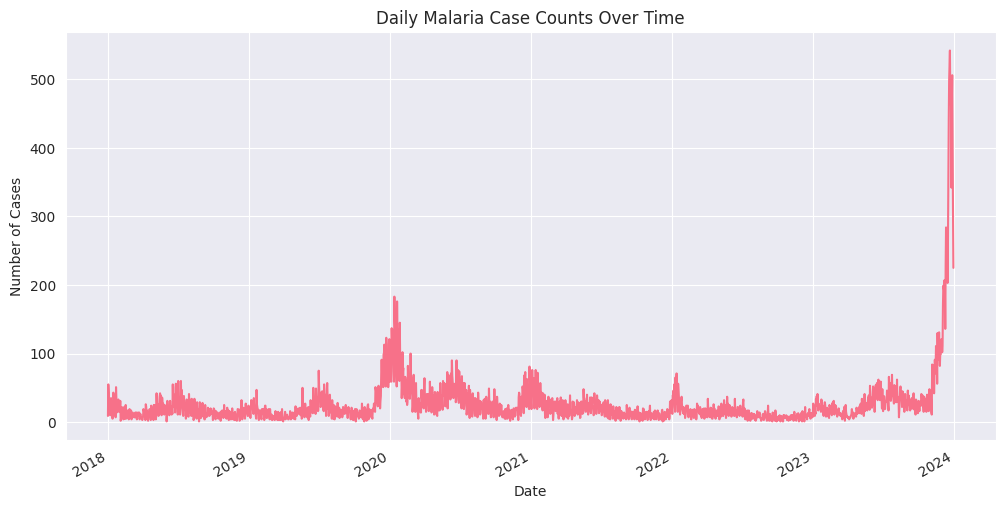

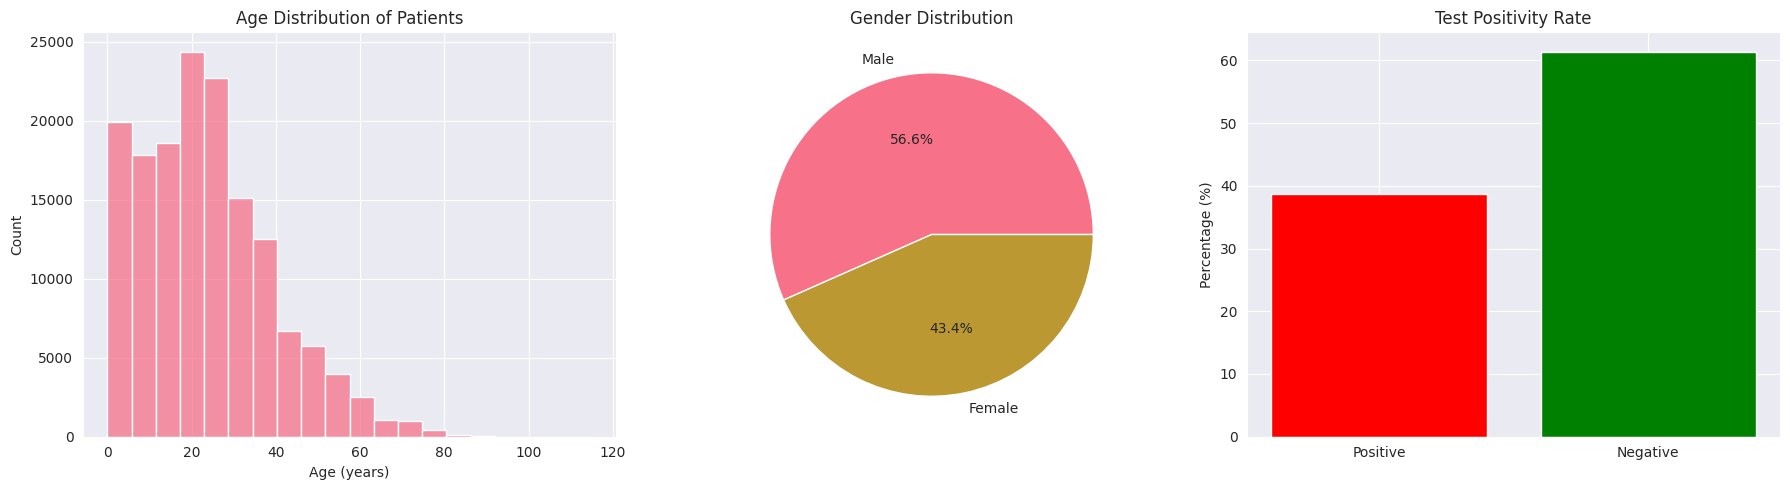

In [184]:
positive_rows = malaria_patients_df[malaria_patients_df['Malaria Positive'] == True]
# Plot temporal distribution of malaria cases
plt.figure(figsize=(12, 6))
positive_rows["Date"].value_counts().sort_index().plot()
plt.title("Daily Malaria Case Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.grid(True)
plt.show()

# Demographic breakdown
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
sns.histplot(malaria_patients_df["Age In Years"], bins=20, ax=axes[0])
axes[0].set_title("Age Distribution of Patients")
axes[0].set_xlabel("Age (years)")

# Gender distribution
gender_counts = malaria_patients_df["Sex"].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
axes[1].set_title("Gender Distribution")

# Case positivity rate
positive_rate = malaria_patients_df["Malaria Positive"].mean() * 100
axes[2].bar(["Positive", "Negative"], 
            [positive_rate, 100-positive_rate],
            color=['red', 'green'])
axes[2].set_title("Test Positivity Rate")
axes[2].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()


In [185]:

# Ensure climate data has proper date format
# final_climate_df = pd.read_csv("../final_normalized_daily_climate_data.csv", low_memory=False)
final_climate_df=final_daily_climate_df
final_climate_df["Date"] = pd.to_datetime(final_daily_climate_df["Date"])

---

### 🔄 Data Cleaning and Harmonization of District Names for Merging

This cell standardizes district names across two datasets (`final_climate_df` and `malaria_patients_df`) to ensure accurate merging on the `District` and `Date` fields.

#### Step 1: Normalize District Names

* **Function:** `clean_district_name`
* **Actions:**

  * Convert all district names to uppercase for uniformity.
  * Remove extra spaces by splitting and rejoining with a single space.
  * Preserve `NaN` values to handle missing data downstream.

#### Step 2: Inspect Unique District Names

* After cleaning, unique district names can be reviewed to identify any inconsistencies or anomalies.

#### Step 3: Apply Manual Corrections (Optional)

* A dictionary of specific manual mappings fixes known issues like extra spaces or misspellings (e.g., `'MAGHARIBI  A'` → `'MAGHARIBI A'`).
* This step ensures that all district names align perfectly between datasets.

#### Step 4: Handle Missing District Values

* Rows with missing (`NaN`) `District` values in the malaria patient dataset are dropped to avoid merge errors.
* Alternatively, missing districts could be imputed if suitable.

#### Final Note:

* The cleaned datasets are now ready for merging on `District` and `Date`.
* Print statements verify the cleaned unique district names in both datasets for confirmation.

---

In [186]:
# Step 1: Normalize spacing and case
def clean_district_name(name):
    if pd.isna(name):
        return name
    return ' '.join(name.upper().split())  # Removes extra spaces and converts to uppercase

final_climate_df['District'] = final_climate_df['District'].apply(clean_district_name)
malaria_patients_df['District'] = malaria_patients_df['District'].apply(clean_district_name)

# Step 2: Check for unique district names after cleaning

# Step 3: Optional manual mapping (if needed)
# If you still spot any unmatched or misspelled district names, you can fix them here
district_corrections = {
    'MAGHARIBI A': 'MAGHARIBI A',
    'MAGHARIBI B': 'MAGHARIBI B',
    'MAGHARIBI  A': 'MAGHARIBI A',
    'MAGHARIBI  B': 'MAGHARIBI B',
}

final_climate_df['District'] = final_climate_df['District'].replace(district_corrections)
malaria_patients_df['District'] = malaria_patients_df['District'].replace(district_corrections)

# Step 4: Drop rows with missing Districts (or you could impute if appropriate)
malaria_patients_df = malaria_patients_df.dropna(subset=['District'])

# Now merge (assuming both have a 'Date' column too)
# merged_df = pd.merge(final_climate_df, malaria_patients_df, on=['District', 'Date'], how='inner')

# Check result
# print(merged_df.head())
# malaria_patients_df["District"].unique().sum()
# malaria_patients_df["Date"].unique()

print("Climate Districts:", final_climate_df['District'].unique())
print("Malaria Districts:", malaria_patients_df['District'].unique())

Climate Districts: ['MKOANI' 'MAGHARIBI A' 'CHAKE-CHAKE' 'KASKAZINI A' 'KASKAZINI B' 'KUSINI'
 'MICHEWENI' 'MJINI' 'WETE' 'MAGHARIBI B']
Malaria Districts: ['MJINI' 'MAGHARIBI A' 'KUSINI' 'MAGHARIBI B' 'MICHEWENI' 'WETE' 'KATI'
 'KASKAZINI A' 'KASKAZINI B' 'MKOANI' 'CHAKE-CHAKE']


In [187]:
malaria_patients_df = malaria_patients_df.dropna(subset=['District'])


In [188]:
final_climate_df = final_climate_df.sort_values(by='Date')
final_climate_df

,District,Station,Island,Net_distribution,Longitude,Latitude,Date,Rainfall,Max_temperature,Min_temperature,Humidity
8764,KASKAZINI B,Mahonda,Unguja,178072.0,39.40,-5.98,2018-01-01,0.78,32.57,26.16,74.25
19719,MAGHARIBI B,Zanzibar Airport,Unguja,178072.0,NaN,NaN,2018-01-01,7.34,32.92,25.37,74.25
10955,KUSINI,Makunduchi,Unguja,178072.0,39.58,-6.32,2018-01-01,7.36,32.76,26.11,74.25
2191,MAGHARIBI A,KIZIMBANI-Zanzibar,Unguja,178072.0,NaN,NaN,2018-01-01,1.81,31.47,26.29,74.25
6573,KASKAZINI A,MKOKOTONI-Zanzibar,Unguja,178072.0,39.29,-5.72,2018-01-01,1.97,31.68,26.51,74.25
...,...,...,...,...,...,...,...,...,...,...,...
19718,WETE,Weni,Pemba,248000.0,39.92,-5.72,2023-12-31,23.56,31.40,26.20,88.10
6572,CHAKE-CHAKE,Karume airport Pemba,Pemba,248000.0,NaN,NaN,2023-12-31,0.00,31.68,26.53,88.10
8763,KASKAZINI A,MKOKOTONI-Zanzibar,Unguja,248000.0,39.29,-5.72,2023-12-31,0.00,30.61,25.18,82.00
15336,MICHEWENI,Matangatuani,Pemba,248000.0,40.04,-4.98,2023-12-31,1.13,31.38,25.93,88.10



##  Merging Clinical and Climate Data

We now combine patient records with environmental conditions using:
1. **Exact matching** on diagnosis date and district
2. **Left join** to preserve all clinical records
3. **Data validation** to ensure merge quality

This creates a rich dataset linking individual health outcomes with environmental exposures.


In [189]:

# print(final_climate_df['District'].unique().count())
# print(malaria_patients_df['District'].unique().count())

# Perform the merge operation
clinical_climate_merged_df = pd.merge(
    malaria_patients_df,
    final_climate_df,
    on=["Date", "District"],
    how="left",  # Preserve all patient records
    indicator=True  # Track merge success
)

# Analyze merge results
merge_stats = clinical_climate_merged_df["_merge"].value_counts(normalize=True) * 100
print("\nMerge Success Rates:")
print(merge_stats)

# Remove merge indicator column
clinical_climate_merged_df = clinical_climate_merged_df.drop("_merge", axis=1)

# Handle unmerged records
# if "left_only" in merge_stats:
#     missing_climate = clinical_climate_merged_df[clinical_climate_merged_df["_merge"] == "left_only"]
#     print(f"\nWarning: {len(missing_climate)} patient records could not be matched with climate data")
#     print("Sample of unmatched records:")
#     print(missing_climate[["Date", "District"]].head())
clinical_climate_merged_df


Merge Success Rates:
_merge
both          87.283608
left_only     12.716392
right_only     0.000000
Name: proportion, dtype: float64


,Sn,Malaria Case ID,Household Island,District,Household Shehia,Date,Week,Month,Year,Malaria Positive,...,Occupation,Station,Island,Net_distribution,Longitude,Latitude,Rainfall,Max_temperature,Min_temperature,Humidity
0,70550,117012,UNGUJA,MJINI,KIKWAJUNI BONDENI,2018-01-01,1,1,2018,False,...,Other,VICTORIA GARDEN,Unguja,178072.0,39.19,-6.16,3.39,32.13,25.88,74.25
1,70536,116953,UNGUJA,MAGHARIBI A,KIANGA,2018-01-01,1,1,2018,False,...,Other,KIZIMBANI-Zanzibar,Unguja,178072.0,NaN,NaN,1.81,31.47,26.29,74.25
2,70537,116953,UNGUJA,MAGHARIBI A,KIANGA,2018-01-01,1,1,2018,False,...,Other,KIZIMBANI-Zanzibar,Unguja,178072.0,NaN,NaN,1.81,31.47,26.29,74.25
3,70534,116953,UNGUJA,MAGHARIBI A,KIANGA,2018-01-01,1,1,2018,False,...,Other,KIZIMBANI-Zanzibar,Unguja,178072.0,NaN,NaN,1.81,31.47,26.29,74.25
4,70535,116953,UNGUJA,MAGHARIBI A,KIANGA,2018-01-01,1,1,2018,False,...,Other,KIZIMBANI-Zanzibar,Unguja,178072.0,NaN,NaN,1.81,31.47,26.29,74.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152554,214824,18543,UNGUJA,KASKAZINI B,BUMBWINI MISUFINI,2023-12-31,52,12,2023,False,...,Housewife,Mahonda,Unguja,248000.0,39.40,-5.98,11.49,31.34,25.46,82.00
152555,214926,19361,UNGUJA,KASKAZINI B,BUMBWINI MISUFINI,2023-12-31,52,12,2023,False,...,Student,Mahonda,Unguja,248000.0,39.40,-5.98,11.49,31.34,25.46,82.00
152556,214927,19361,UNGUJA,KASKAZINI B,BUMBWINI MISUFINI,2023-12-31,52,12,2023,False,...,Student,Mahonda,Unguja,248000.0,39.40,-5.98,11.49,31.34,25.46,82.00
152557,NotInvest,UNKNOWN_CASE,UNGUJA,MAGHARIBI B,FUONI KIJITOUPELE,2023-12-31,52,12,2023,True,...,Other,Zanzibar Airport,Unguja,248000.0,NaN,NaN,53.75,30.98,26.10,82.00


In [190]:
print(final_climate_df['District'].value_counts())
print(malaria_patients_df['District'].value_counts())


District
KASKAZINI B    2191
MAGHARIBI B    2191
KUSINI         2191
MAGHARIBI A    2191
KASKAZINI A    2191
MICHEWENI      2191
CHAKE-CHAKE    2191
MJINI          2191
WETE           2191
MKOANI         1461
Name: count, dtype: int64
District
MJINI          38677
MAGHARIBI B    31694
MAGHARIBI A    18473
KATI           17965
KASKAZINI B     9358
KASKAZINI A     8799
WETE            7581
MICHEWENI       7360
KUSINI          5186
CHAKE-CHAKE     4195
MKOANI          3271
Name: count, dtype: int64


In [191]:
clinical_climate_merged_df.isna().sum()

Sn                                    0
Malaria Case ID                       0
Household Island                      0
District                              0
Household Shehia                      0
Date                                  0
Week                                  0
Month                                 0
Year                                  0
Malaria Positive                      0
Travel History                        0
Sex                                   0
Age In Years                          0
AgeGroupLabel                         0
Household Member Type                 0
Facility                              0
Facility District                     0
Facility Type                         0
Household Location - Latitude         0
Household Location - Longitude        0
Occupation                            0
Station                           19400
Island                            19400
Net_distribution                  19400
Longitude                         73762


---

### 🛠️ Imputing Missing Climate Data for KATI District

This cell handles missing climate data specifically for the district `"KATI"` in the merged clinical-climate dataset (`clinical_climate_merged_df`).

#### Step 1: Identify Missing Data Rows

* Filter rows where the district is `"KATI"` and climate columns like `Min_temperature` are missing (`NaN`).

#### Step 2: Prepare Donor Climate Data

* From the full climate dataset (`final_climate_df`), select only rows with complete climate data (no missing values in key columns).

#### Step 3: Sample Replacement Data

* Randomly sample as many rows from the donor climate data as there are missing KATI rows. Sampling is done **with replacement** to ensure enough data.

#### Step 4: Align Indices

* Assign the sampled data the same indices as the missing KATI rows to prepare for direct replacement.

#### Step 5: Impute Missing Values

* For each climate feature (`Min_temperature`, `Max_temperature`, `Rainfall`, `Humidity`, `Net_distribution`), replace missing values in the KATI rows with the corresponding sampled values.

---

This approach uses random sampling from other districts’ complete climate data to realistically fill missing KATI data without introducing bias from a single source.

---


In [192]:
import numpy as np

# Step 1: Identify rows with KATI and missing climate data (e.g., Min_temperature is null)
kati_rows = clinical_climate_merged_df[
    (clinical_climate_merged_df['District'] == 'KATI') &
    (clinical_climate_merged_df['Min_temperature'].isna())
]

# Step 2: Get available climate data from other districts (exclude NaNs)
available_climate_data = final_climate_df.dropna(subset=['Min_temperature', 'Max_temperature', 'Rainfall', 'Humidity', 'Net_distribution'])

# Step 3: Sample random rows from available climate data (same number as KATI rows)
sampled_data = available_climate_data.sample(n=len(kati_rows), replace=True).reset_index(drop=True)

# Step 4: Reset index of KATI rows to align
kati_rows_indices = kati_rows.index
sampled_data.index = kati_rows_indices  # align indices

# Step 5: Fill in missing climate data in the main merged DataFrame
for col in ['Min_temperature', 'Max_temperature', 'Rainfall', 'Humidity', 'Net_distribution']:
    clinical_climate_merged_df.loc[kati_rows_indices, col] = sampled_data[col]

# Now KATI rows have filled-in values from random districts


In [193]:
clinical_climate_merged_df=clinical_climate_merged_df.drop("Longitude", axis=1)
clinical_climate_merged_df=clinical_climate_merged_df.drop("Latitude", axis=1)
clinical_climate_merged_df=clinical_climate_merged_df.drop("Island", axis=1)
clinical_climate_merged_df=clinical_climate_merged_df.drop("Station", axis=1)
clinical_climate_merged_df.isna().sum()

Sn                                   0
Malaria Case ID                      0
Household Island                     0
District                             0
Household Shehia                     0
Date                                 0
Week                                 0
Month                                0
Year                                 0
Malaria Positive                     0
Travel History                       0
Sex                                  0
Age In Years                         0
AgeGroupLabel                        0
Household Member Type                0
Facility                             0
Facility District                    0
Facility Type                        0
Household Location - Latitude        0
Household Location - Longitude       0
Occupation                           0
Net_distribution                  1435
Rainfall                          1435
Max_temperature                   1435
Min_temperature                   1435
Humidity                 

In [194]:
clinical_climate_merged_df = clinical_climate_merged_df.dropna(subset=['Min_temperature'])

In [195]:
clinical_climate_merged_df.isna().sum()

Sn                                0
Malaria Case ID                   0
Household Island                  0
District                          0
Household Shehia                  0
Date                              0
Week                              0
Month                             0
Year                              0
Malaria Positive                  0
Travel History                    0
Sex                               0
Age In Years                      0
AgeGroupLabel                     0
Household Member Type             0
Facility                          0
Facility District                 0
Facility Type                     0
Household Location - Latitude     0
Household Location - Longitude    0
Occupation                        0
Net_distribution                  0
Rainfall                          0
Max_temperature                   0
Min_temperature                   0
Humidity                          0
dtype: int64

   Year  IRS coverage (%)
0  2018              95.0
1  2019              95.2
2  2020              96.9
3  2021              94.7
4  2022              97.8


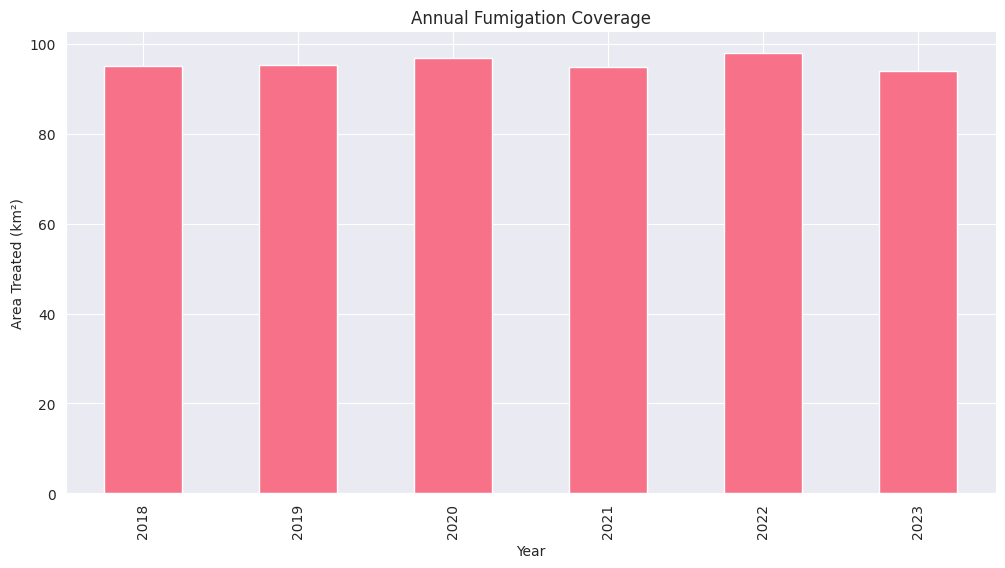

      Sn Malaria Case ID Household Island     District   Household Shehia  \
0  70550          117012           UNGUJA        MJINI  KIKWAJUNI BONDENI   
1  70536          116953           UNGUJA  MAGHARIBI A             KIANGA   
2  70537          116953           UNGUJA  MAGHARIBI A             KIANGA   
3  70534          116953           UNGUJA  MAGHARIBI A             KIANGA   
4  70535          116953           UNGUJA  MAGHARIBI A             KIANGA   

        Date  Week  Month  Year  Malaria Positive  ... Facility Type  \
0 2018-01-01     1      1  2018             False  ...        PUBLIC   
1 2018-01-01     1      1  2018             False  ...        PUBLIC   
2 2018-01-01     1      1  2018             False  ...        PUBLIC   
3 2018-01-01     1      1  2018             False  ...        PUBLIC   
4 2018-01-01     1      1  2018             False  ...        PUBLIC   

  Household Location - Latitude  Household Location - Longitude Occupation  \
0                     -5.9

In [196]:

# Load fumigation records
fumigation_df = pd.read_excel('../RawDataset/fumigation_area.xlsx')

print(fumigation_df.head())
# Visualize fumigation coverage over time
plt.figure(figsize=(12, 6))
fumigation_df.groupby("Year")["IRS coverage (%)"].sum().plot(kind="bar")
plt.title("Annual Fumigation Coverage")
plt.ylabel("Area Treated (km²)")
plt.xlabel("Year")
plt.show()

# Merge fumigation data with clinical-climate dataset
final_merged_df = pd.merge(
    clinical_climate_merged_df,
    fumigation_df,
    on=["Year"],
    how="left"
)

# Save intermediate result
final_merged_df.to_csv("../final_combined_normalized_daily_climate_data.csv", index=False)
print(final_merged_df.head())

In [197]:
null_min_temp_rows = final_merged_df[final_merged_df['Min_temperature'].isna()]
null_min_temp_rows["District"].unique()


array([], dtype=object)

In [198]:
final_merged_df.isna().sum()

Sn                                0
Malaria Case ID                   0
Household Island                  0
District                          0
Household Shehia                  0
Date                              0
Week                              0
Month                             0
Year                              0
Malaria Positive                  0
Travel History                    0
Sex                               0
Age In Years                      0
AgeGroupLabel                     0
Household Member Type             0
Facility                          0
Facility District                 0
Facility Type                     0
Household Location - Latitude     0
Household Location - Longitude    0
Occupation                        0
Net_distribution                  0
Rainfall                          0
Max_temperature                   0
Min_temperature                   0
Humidity                          0
IRS coverage (%)                  0
dtype: int64

In [199]:
final_merged_df.info()
# final_merged_df.to_csv("../final_dataset_combined_everything.csv", index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151124 entries, 0 to 151123
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Sn                              151124 non-null  object        
 1   Malaria Case ID                 151124 non-null  object        
 2   Household Island                151124 non-null  object        
 3   District                        151124 non-null  object        
 4   Household Shehia                151124 non-null  object        
 5   Date                            151124 non-null  datetime64[ns]
 6   Week                            151124 non-null  int64         
 7   Month                           151124 non-null  int64         
 8   Year                            151124 non-null  int64         
 9   Malaria Positive                151124 non-null  bool          
 10  Travel History                  151124 non-null  object 

In [200]:
final_merged_df = pd.read_csv("../final_dataset_combined_everything.csv")

In [201]:
# View unique values in a column
final_merged_df["Household Member Type"].unique()

# Drop multiple columns at once
final_merged_df = final_merged_df.drop([
    "AgeGroupLabel",
    "Household Member Type",
    "Facility",
    "Facility District",
    "Facility Type",
    "Occupation",
    "Household Location - Latitude",
    "Household Location - Longitude",
    "Age In Years",
    "Sex",
    "Travel History",
    "Household Island",
    "Household Shehia",
    "Sn",
    "Malaria Case ID",
    "Month",
    "Week"
], axis=1)


In [202]:
final_merged_df

,District,Date,Year,Malaria Positive,Net_distribution,Rainfall,Max_temperature,Min_temperature,Humidity,IRS coverage (%)
0,MJINI,2018-01-01,2018,False,178072.0,3.75,32.19,25.61,73.70,95.0
1,MAGHARIBI A,2018-01-01,2018,False,178072.0,1.72,33.58,25.96,73.70,95.0
2,MAGHARIBI A,2018-01-01,2018,False,178072.0,1.72,33.58,25.96,73.70,95.0
3,MAGHARIBI A,2018-01-01,2018,False,178072.0,1.72,33.58,25.96,73.70,95.0
4,MAGHARIBI A,2018-01-01,2018,False,178072.0,1.72,33.58,25.96,73.70,95.0
...,...,...,...,...,...,...,...,...,...,...
151119,KASKAZINI B,2023-12-31,2023,False,248000.0,11.77,31.70,25.39,79.95,94.0
151120,KASKAZINI B,2023-12-31,2023,False,248000.0,11.77,31.70,25.39,79.95,94.0
151121,KASKAZINI B,2023-12-31,2023,False,248000.0,11.77,31.70,25.39,79.95,94.0
151122,MAGHARIBI B,2023-12-31,2023,True,248000.0,48.23,31.24,27.88,79.95,94.0


# Date structure handling
> representing data in separate ways to have the day month and year
### this help to capture more detailed time based patterns

In [203]:
import pandas as pd

# Convert 'Date' column to datetime
final_merged_df['Date'] = pd.to_datetime(final_merged_df['Date'])

# Create separate 'Day' and 'Month' columns
final_merged_df['Day'] = final_merged_df['Date'].dt.day
final_merged_df['Month'] = final_merged_df['Date'].dt.month

# (Optional) Drop the original 'Date' column if it's no longer needed
final_merged_df = final_merged_df.drop('Date', axis=1)
final_merged_df

,District,Year,Malaria Positive,Net_distribution,Rainfall,Max_temperature,Min_temperature,Humidity,IRS coverage (%),Day,Month
0,MJINI,2018,False,178072.0,3.75,32.19,25.61,73.70,95.0,1,1
1,MAGHARIBI A,2018,False,178072.0,1.72,33.58,25.96,73.70,95.0,1,1
2,MAGHARIBI A,2018,False,178072.0,1.72,33.58,25.96,73.70,95.0,1,1
3,MAGHARIBI A,2018,False,178072.0,1.72,33.58,25.96,73.70,95.0,1,1
4,MAGHARIBI A,2018,False,178072.0,1.72,33.58,25.96,73.70,95.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
151119,KASKAZINI B,2023,False,248000.0,11.77,31.70,25.39,79.95,94.0,31,12
151120,KASKAZINI B,2023,False,248000.0,11.77,31.70,25.39,79.95,94.0,31,12
151121,KASKAZINI B,2023,False,248000.0,11.77,31.70,25.39,79.95,94.0,31,12
151122,MAGHARIBI B,2023,True,248000.0,48.23,31.24,27.88,79.95,94.0,31,12


In [204]:
final_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151124 entries, 0 to 151123
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   District          151124 non-null  object 
 1   Year              151124 non-null  int64  
 2   Malaria Positive  151124 non-null  bool   
 3   Net_distribution  151124 non-null  float64
 4   Rainfall          151124 non-null  float64
 5   Max_temperature   151124 non-null  float64
 6   Min_temperature   151124 non-null  float64
 7   Humidity          151124 non-null  float64
 8   IRS coverage (%)  151124 non-null  float64
 9   Day               151124 non-null  int32  
 10  Month             151124 non-null  int32  
dtypes: bool(1), float64(6), int32(2), int64(1), object(1)
memory usage: 10.5+ MB


---

### 📊 Aggregating Malaria and Climate Data

This cell performs aggregation on the merged dataset `final_merged_df` to create summarized views for analysis.

#### Step 1: Create a Malaria Case Count

* Adds a helper column `'Malaria Case Count'` where each malaria positive case is counted as `1`, and negative cases as `0`.

#### Step 2: Aggregate Daily Data (All Districts Combined)

* Groups data by `Year`, `Month`, and `Day` to summarize on a daily basis across all districts.
* Aggregations performed:

  * Sum of malaria cases (`Malaria Case Count`).
  * Mean values of climate variables like net distribution, rainfall, temperature, humidity, and IRS coverage.

#### Step 3: Aggregate Daily Data by District

* Groups data by `District`, `Year`, `Month`, and `Day` to get district-level daily summaries.
* Same aggregation methods as the overall daily summary.

#### Optional Step:

* Drops the original boolean `'Malaria Positive'` column since it is now represented in aggregated form.

---

In [205]:
import pandas as pd

# Step 1: Create a helper column for counting only positive cases
final_merged_df['Malaria Case Count'] = final_merged_df['Malaria Positive'].apply(lambda x: 1 if x else 0)

# -------- FIRST DATAFRAME: Group by Year-Month-Day only --------
df_daily = (
    final_merged_df
    .groupby(['Year', 'Month', 'Day'], as_index=False)
    .agg({
        'Malaria Case Count': 'sum',
        'Net_distribution': 'mean',
        'Rainfall': 'mean',
        'Max_temperature': 'mean',
        'Min_temperature': 'mean',
        'Humidity': 'mean',
        'IRS coverage (%)': 'mean',
        # Add other relevant columns here as needed
    })
)

# -------- SECOND DATAFRAME: Group by District + Year-Month-Day --------
df_district_daily = (
    final_merged_df
    .groupby(['District', 'Year', 'Month', 'Day'], as_index=False)
    .agg({
        'Malaria Case Count': 'sum',
        'Net_distribution': 'mean',
        'Rainfall': 'mean',
        'Max_temperature': 'mean',
        'Min_temperature': 'mean',
        'Humidity': 'mean',
        'IRS coverage (%)': 'mean',
        # Add other relevant columns here as needed
    })
)

# Optional: Drop original 'Malaria Positive' column from the main DataFrame
final_merged_df = final_merged_df.drop('Malaria Positive', axis=1)


In [206]:
df_district_daily

,District,Year,Month,Day,Malaria Case Count,Net_distribution,Rainfall,Max_temperature,Min_temperature,Humidity,IRS coverage (%)
0,CHAKE-CHAKE,2018,1,2,1,178072.0,1.76,32.37,25.40,89.1,95.0
1,CHAKE-CHAKE,2018,1,3,4,178072.0,1.87,32.86,25.82,91.6,95.0
2,CHAKE-CHAKE,2018,1,4,0,178072.0,1.68,32.13,25.83,88.4,95.0
3,CHAKE-CHAKE,2018,1,5,2,178072.0,1.75,32.96,25.81,90.1,95.0
4,CHAKE-CHAKE,2018,1,7,0,178072.0,2.04,33.49,25.38,89.9,95.0
...,...,...,...,...,...,...,...,...,...,...,...
15874,WETE,2023,12,27,8,248000.0,11.95,31.52,26.56,90.1,94.0
15875,WETE,2023,12,28,11,248000.0,12.65,31.14,26.22,91.9,94.0
15876,WETE,2023,12,29,6,248000.0,12.45,31.33,26.21,88.4,94.0
15877,WETE,2023,12,30,3,248000.0,14.96,30.52,26.46,90.9,94.0


In [207]:
df_daily

,Year,Month,Day,Malaria Case Count,Net_distribution,Rainfall,Max_temperature,Min_temperature,Humidity,IRS coverage (%)
0,2018,1,1,9,178072.000000,4.818545,32.532727,25.663636,74.676364,95.0
1,2018,1,2,54,193094.922772,3.819109,32.564950,25.645842,74.252970,95.0
2,2018,1,3,41,191838.294017,3.891368,32.938291,25.719145,81.122222,95.0
3,2018,1,4,20,186824.400000,5.113625,32.489625,25.806625,83.409375,95.0
4,2018,1,5,12,181025.466667,3.290000,32.676667,25.314667,79.496667,95.0
...,...,...,...,...,...,...,...,...,...,...
2183,2023,12,27,467,255742.291194,12.978650,30.845440,26.088415,83.134834,94.0
2184,2023,12,28,506,261616.099703,13.333012,31.053442,26.267315,80.713872,94.0
2185,2023,12,29,395,255548.433652,12.062352,31.868126,25.681491,83.590440,94.0
2186,2023,12,30,308,252344.303673,15.369143,31.560184,25.102327,82.256633,94.0


---

### 🚨 Defining Malaria Outbreak Thresholds

This cell calculates **outbreak detection thresholds** using two statistical approaches for both daily and district-level malaria case counts:

#### ✅ Step 1: IQR-Based Threshold (Outlier Detection)

* For both `df_daily` and `df_district_daily`, it calculates:

  * **Q1 (25th percentile)** and **Q3 (75th percentile)** of `Malaria Case Count`
  * **Interquartile Range (IQR)** = Q3 − Q1
  * **Outbreak threshold** = Q3 + 1.5 × IQR
    *(Any value above this is considered unusually high — a potential outbreak)*

#### ✅ Step 2: Standard Deviation-Based Threshold

* Calculates the **mean** and **standard deviation (std)** of `Malaria Case Count`
* Defines a new outbreak threshold as:

  * **Threshold** = mean + 2 × std
    *(You could use 3×std for a stricter threshold)*

#### 📌 Purpose:

These thresholds help in **automatically detecting abnormal spikes** in malaria cases, either:

* Across all districts on a given day (`df_daily`)
* Or in a specific district per day (`df_district_daily`)

---

In [208]:
# For df_daily
Q1 = df_daily['Malaria Case Count'].quantile(0.25)
Q3 = df_daily['Malaria Case Count'].quantile(0.75)
IQR = Q3 - Q1
daily_threshold = Q3 + 1.5 * IQR

# For df_district_daily
Q1_district = df_district_daily['Malaria Case Count'].quantile(0.25)
Q3_district = df_district_daily['Malaria Case Count'].quantile(0.75)
IQR_district = Q3_district - Q1_district
district_threshold = Q3_district + 1.5 * IQR_district

print("General Outbreak Threshold:", daily_threshold)
print("District-level Outbreak Threshold:", district_threshold)


General Outbreak Threshold: 60.0
District-level Outbreak Threshold: 8.5


In [209]:
# For df_daily
mean_daily = df_daily['Malaria Case Count'].mean()
std_daily = df_daily['Malaria Case Count'].std()
daily_threshold = mean_daily + 2 * std_daily  # or 3 * std_daily

# For df_district_daily
mean_district = df_district_daily['Malaria Case Count'].mean()
std_district = df_district_daily['Malaria Case Count'].std()
district_threshold = mean_district + 2 * std_district  # or 3 * std_district

print("General Outbreak Threshold:", daily_threshold)
print("District-level Outbreak Threshold:", district_threshold)


General Outbreak Threshold: 111.35190198082023
District-level Outbreak Threshold: 22.93590095645847


## Encoding the district column using the label encoder
### here we convert the district that are in the categorical format into number

In [210]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
label_encoder = LabelEncoder()

# Apply to df_district_daily
df_district_daily['District_encoded'] = label_encoder.fit_transform(df_district_daily['District'])

# Optional: Save mapping for interpretation
district_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

# Show mapping
print("District Encoding Mapping:")
for district, code in district_mapping.items():
    print(f"{district}: {code}")


District Encoding Mapping:
CHAKE-CHAKE: 0
KASKAZINI A: 1
KASKAZINI B: 2
KATI: 3
KUSINI: 4
MAGHARIBI A: 5
MAGHARIBI B: 6
MICHEWENI: 7
MJINI: 8
MKOANI: 9
WETE: 10


In [211]:
df_district_daily = df_district_daily.drop('District', axis=1)

# the correclation matrix to showw the relationsship between different columns in a dataset

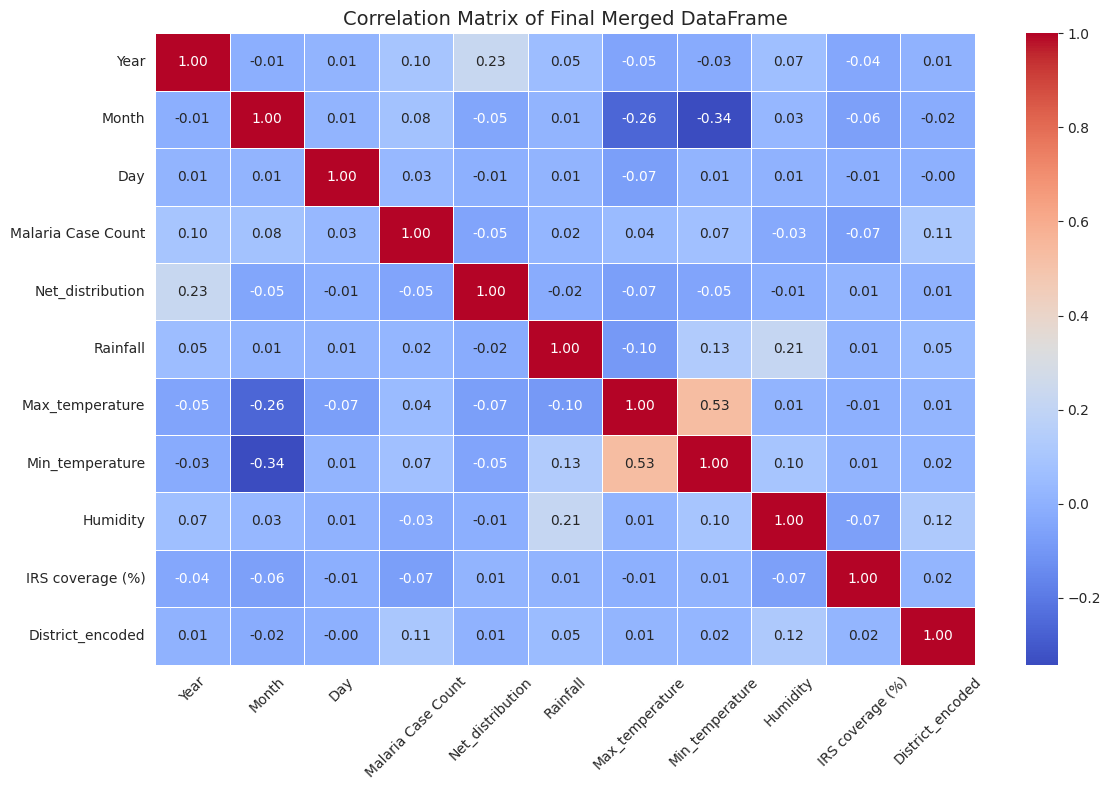

In [212]:
corr_matrix = df_district_daily.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Final Merged DataFrame", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [213]:
df_district_daily
df_district_daily["Outbreak"] = df_district_daily["Malaria Case Count"] > 8.5
df_district_daily = df_district_daily.drop("Malaria Case Count", axis=1)
df_daily["Outbreak"] = df_daily["Malaria Case Count"] > 61
df_daily = df_daily.drop("Malaria Case Count", axis=1)

---

### 🧠 Machine Learning Models for Malaria Outbreak Prediction

This cell trains and evaluates several classification models to predict **malaria outbreaks** based on climate and case data.

#### ✅ Step-by-Step Breakdown:

1. **Data Preparation**

   * Features `X`: All columns except `Outbreak` from `df_district_daily`
   * Target `y`: The `Outbreak` column (binary classification)
   * Data is **standardized** using `StandardScaler`

2. **Train-Test Split**

   * Splits the dataset into 80% training and 20% testing

3. **Models Used**

   * Logistic Regression
   * Random Forest
   * Gradient Boosting
   * Decision Tree
   * Support Vector Machine (SVM)

4. **Model Training and Evaluation**

   * Each model is trained on the training data
   * Predictions are made on the test set
   * Accuracy, confusion matrix, and classification report are computed

5. **Visualization**

   * A bar chart compares the **accuracy** of each model

#### 📌 Goal:

To identify the best-performing model for predicting **daily malaria outbreaks at the district level**, enabling early warning systems and preventive interventions.

---

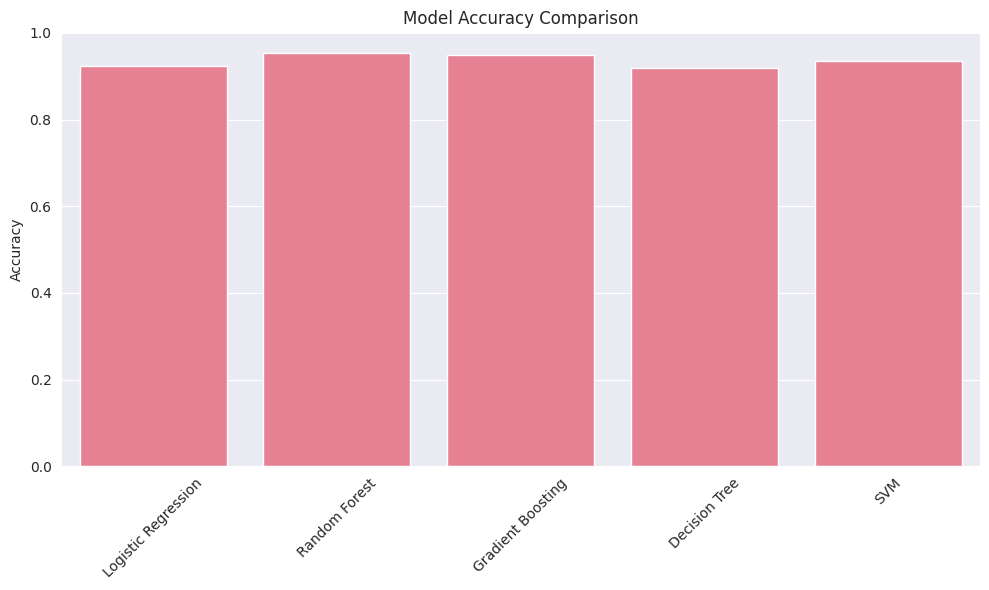

In [214]:
import os
import joblib  # For saving models

# Create a directory for saving models if it doesn't exist
os.makedirs("models", exist_ok=True)

X = df_district_daily.drop("Outbreak", axis=1)
y = df_district_daily["Outbreak"]
X
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', probability=True)
}

# Train, evaluate, save, and collect results
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Save model
    filename = f"../models/{name.replace(' ', '_')}_model.pkl"
    joblib.dump(model, filename)
    
    results[name] = {
        "model": model,
        "accuracy": acc,
        "conf_matrix": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }

# Plotting accuracy comparison
accuracies = [results[m]["accuracy"] for m in models]
plt.figure(figsize=(10, 6))
sns.barplot(x=list(models.keys()), y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---

### 🌳 Feature Importance from Tree-Based Models

This section visualizes and compares **feature importance scores** from three tree-based machine learning models:

* **Random Forest**
* **Gradient Boosting**
* **Decision Tree**

#### 🔍 What it does:

1. Extracts feature importances from each trained model.
2. Combines them into a single DataFrame for comparison.
3. Plots a **bar chart** to highlight which features are most influential in predicting **malaria outbreaks**.

#### 📊 Why it matters:

* Helps identify **key predictors** such as rainfall, temperature, humidity, or mosquito net distribution.
* Supports feature selection and improves **model interpretability**.

---


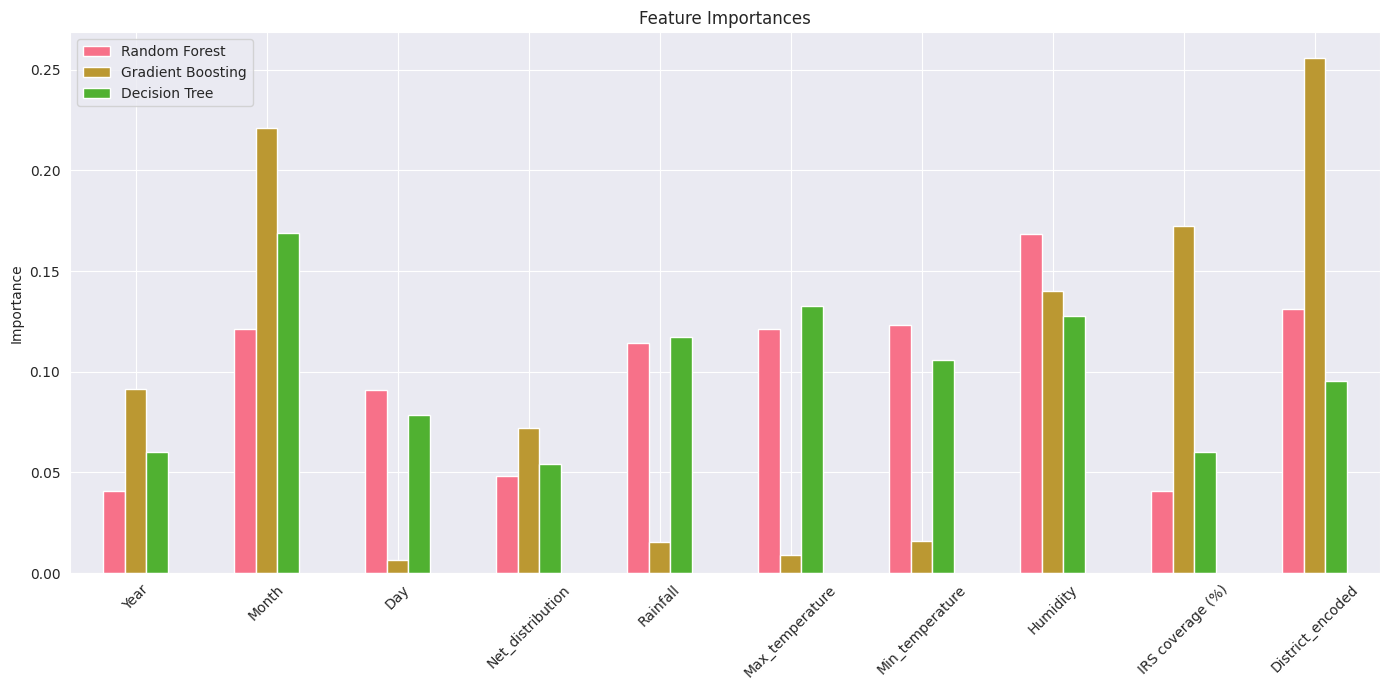

,Random Forest,Gradient Boosting,Decision Tree
Year,0.040727,0.091474,0.060122
Month,0.121294,0.220862,0.168757
Day,0.090932,0.006709,0.078275
Net_distribution,0.048101,0.072288,0.053991
Rainfall,0.114220,0.015690,0.117304
Max_temperature,0.121125,0.009222,0.132458
Min_temperature,0.123303,0.015909,0.105760
Humidity,0.168525,0.139979,0.127676
IRS coverage (%),0.040641,0.172148,0.060269
District_encoded,0.131133,0.255720,0.095390


In [215]:
# Feature importance for tree-based models
importance_df = pd.DataFrame()
for name in ['Random Forest', 'Gradient Boosting', 'Decision Tree']:
    model = results[name]['model']
    importance_df[name] = model.feature_importances_
    
feature_columns = [col for col in X.columns]

importance_df.index = feature_columns
importance_df.plot(kind='bar', figsize=(14, 7), title="Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

importance_df.head(10)


---

### 🤖 Modeling Malaria Case Counts (Regression-like Setup)

This section trains and evaluates multiple machine learning models to **predict the number of malaria cases per day** using daily climate and intervention data.

#### 🧮 Steps Included:

1. **Feature & Label Definition**

   * **Features (`X`)**: All columns except `Malaria Case Count`
   * **Label (`y`)**: Malaria Case Count

2. **Data Preprocessing**

   * Standardization using `StandardScaler`
   * Train-test split (80% training, 20% testing)

3. **Model Training and Evaluation**
   Models used:

   * Logistic Regression (treated as a baseline)
   * Random Forest
   * Gradient Boosting
   * Decision Tree
   * Support Vector Machine (SVM)

   For each model:

   * Accuracy is computed (note: this metric is better suited for classification; RMSE/MAE might be more appropriate for regression)
   * Confusion matrix and classification report are stored

4. **Accuracy Visualization**
   A bar chart compares each model’s predictive accuracy.

---

### 🌳 Feature Importance for Tree-Based Models

For interpretability, the feature importances from:

* Random Forest
* Gradient Boosting
* Decision Tree

are extracted and visualized in a **side-by-side bar chart** to identify which features most impact malaria case predictions.

---

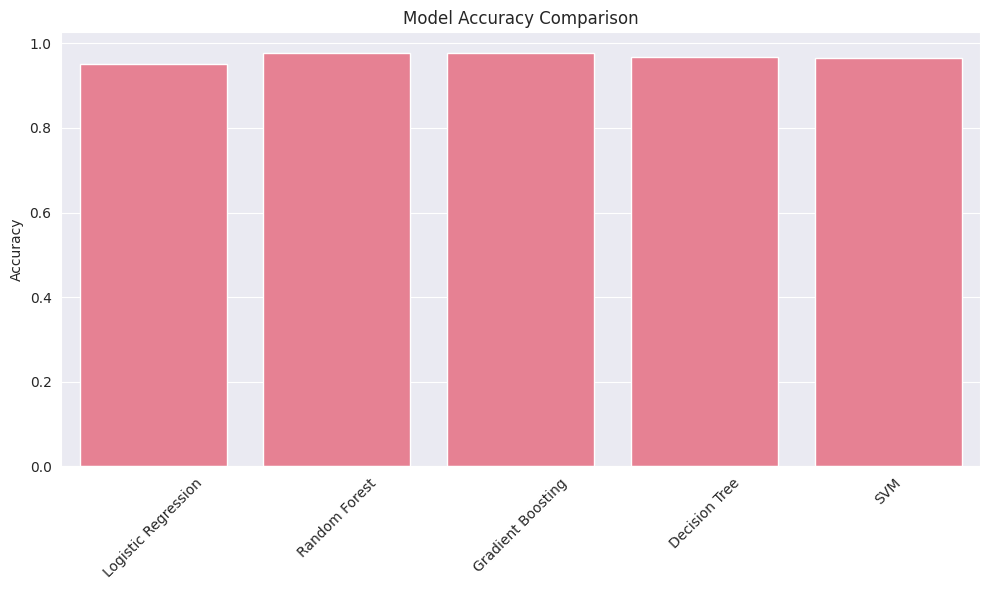

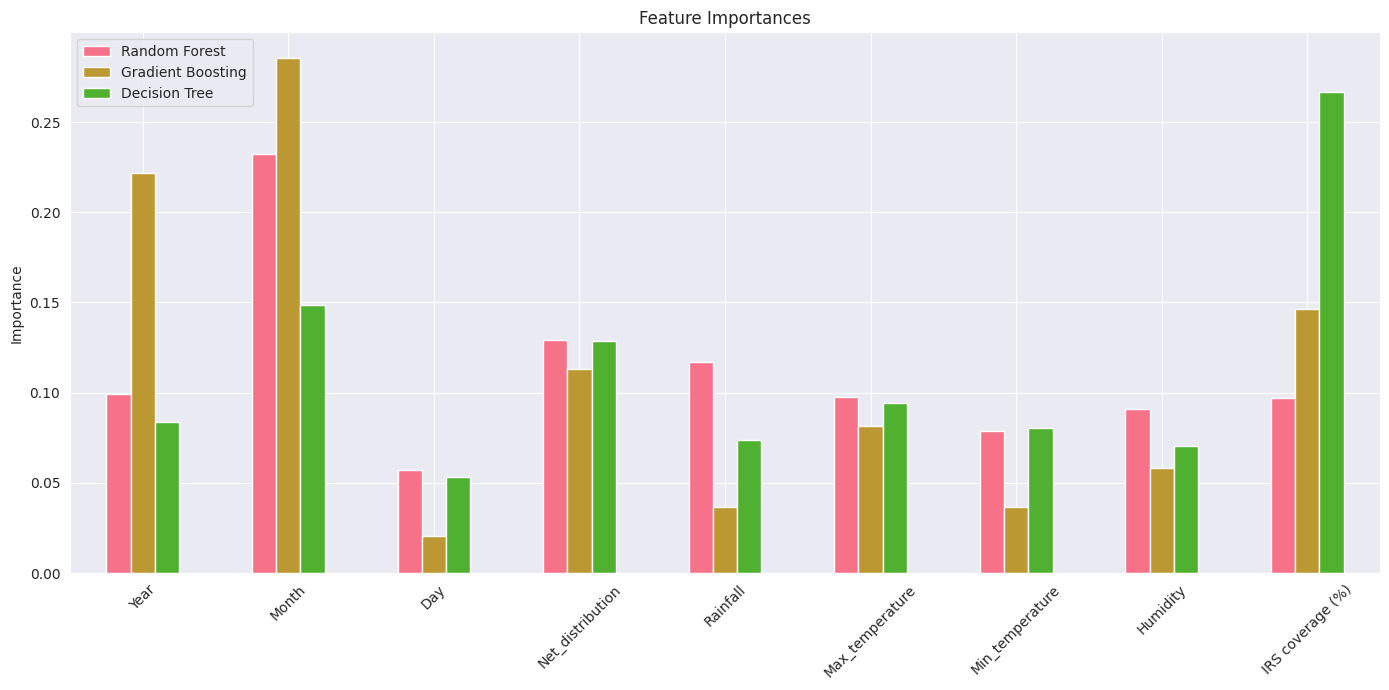

,Random Forest,Gradient Boosting,Decision Tree
Year,0.099452,0.221693,0.083949
Month,0.232491,0.285457,0.148521
Day,0.057408,0.020712,0.053151
Net_distribution,0.129409,0.113162,0.128701
Rainfall,0.117009,0.036732,0.073876
Max_temperature,0.097606,0.081568,0.094089
Min_temperature,0.078936,0.036385,0.080479
Humidity,0.090826,0.058083,0.070511
IRS coverage (%),0.096862,0.146210,0.266724


In [216]:
X = df_daily.drop("Outbreak", axis=1)
y = df_daily["Outbreak"]

# Scale the features
daily_scaler = StandardScaler()
X_scaled = daily_scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', probability=True)
}

# Train, evaluate and collect results
daily_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Save model
    filename = f"../models/{name.replace(' ', '_')}_daily_model.pkl"
    joblib.dump(model, filename)
    
    daily_results[name] = {
        "model": model,
        "accuracy": acc,
        "conf_matrix": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }

# Plotting accuracy comparison
accuracies = [daily_results[m]["accuracy"] for m in models]
plt.figure(figsize=(10, 6))
sns.barplot(x=list(models.keys()), y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Feature importance for tree-based models
importance_df = pd.DataFrame()
for name in ['Random Forest', 'Gradient Boosting', 'Decision Tree']:
    model = daily_results[name]['model']
    importance_df[name] = model.feature_importances_

importance_df.index = [col for col in X.columns]
importance_df.plot(kind='bar', figsize=(14, 7), title="Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

importance_df.head(10)

### 🧪 Test Case 1: District-Level Outbreak Prediction (User Input)

In this test case, the user is prompted to enter real-world values for district-level features (e.g., Rainfall, Humidity, etc.). These values are scaled and passed to the best-performing classification model to predict whether there will be a **malaria outbreak (1)** or **no outbreak (0)** in the district.


## 🧪 District-Level Malaria Outbreak Prediction

Please provide the following input values for prediction. The model will use your input to predict whether a malaria outbreak will occur in the specified district.

**District Encoding:**
- CHAKE-CHAKE: `0`
- KASKAZINI A: `1`
- KASKAZINI B: `2`
- KATI: `3`
- KUSINI: `4`
- MAGHARIBI A: `5`
- MAGHARIBI B: `6`
- MICHEWENI: `7`
- MJINI: `8`
- MKOANI: `9`
- WETE: `10`

Provide inputs for the following fields:

- `Year`, `Month`, `Day`
- `Net_distribution`, `Rainfall`
- `Max_temperature`, `Min_temperature`
- `Humidity`, `IRS coverage (%)`
- `District_encoded` (as described above)


# predict the district based malaria outbreak

In [217]:
# Prompt user for input values
input_data = {
    "Year": float(input("Enter Year: ")),
    "Month": float(input("Enter Month: ")),
    "Day": float(input("Enter Day: ")),
    "Net_distribution": float(input("Enter Net Distribution: ")),
    "Rainfall": float(input("Enter Rainfall (mm): ")),
    "Max_temperature": float(input("Enter Max Temperature (°C): ")),
    "Min_temperature": float(input("Enter Min Temperature (°C): ")),
    "Humidity": float(input("Enter Humidity (%): ")),
    "IRS coverage (%)": float(input("Enter IRS Coverage (%): ")),
    "District_encoded": int(input("Enter District Code (0 to 10): "))
}

# Convert input to DataFrame
user_input_df = pd.DataFrame([input_data])

# Apply the same scaling
user_input_scaled = scaler.transform(user_input_df)

# Predict using best-performing model (or choose your model)
best_model = results["Random Forest"]["model"]
prediction = best_model.predict(user_input_scaled)
print(prediction)

# Output prediction
print("\nPrediction Result:")
print("🚨 Outbreak" if prediction[0] == True else "✅ No Outbreak")


Enter Year:  2025
Enter Month:  12
Enter Day:  23
Enter Net Distribution:  179000
Enter Rainfall (mm):  30
Enter Max Temperature (°C):  29
Enter Min Temperature (°C):  22
Enter Humidity (%):  50
Enter IRS Coverage (%):  80
Enter District Code (0 to 10):  6


[ True]

Prediction Result:
🚨 Outbreak


# predict general malaria outbreak

In [218]:
# Prompt user for input values
input_data = {
    "Year": float(input("Enter Year: ")),
    "Month": float(input("Enter Month: ")),
    "Day": float(input("Enter Day: ")),
    "Net_distribution": float(input("Enter Net Distribution: ")),
    "Rainfall": float(input("Enter Rainfall (mm): ")),
    "Max_temperature": float(input("Enter Max Temperature (°C): ")),
    "Min_temperature": float(input("Enter Min Temperature (°C): ")),
    "Humidity": float(input("Enter Humidity (%): ")),
    "IRS coverage (%)": float(input("Enter IRS Coverage (%): ")),
}

# Convert input to DataFrame
user_input_df = pd.DataFrame([input_data])

# Apply the same scaling
user_input_scaled = daily_scaler.transform(user_input_df)

# Predict using best-performing model (or choose your model)
best_model = daily_results["Random Forest"]["model"]
prediction = best_model.predict(user_input_scaled)
print(prediction)

# Output prediction
print("\nPrediction Result:")
print("🚨 Outbreak" if prediction[0] == True else "✅ No Outbreak")


Enter Year:  6
Enter Month:  7
Enter Day:  7
Enter Net Distribution:  7
Enter Rainfall (mm):  7
Enter Max Temperature (°C):  7
Enter Min Temperature (°C):  7
Enter Humidity (%):  7
Enter IRS Coverage (%):  7


[False]

Prediction Result:
✅ No Outbreak
